# Two-Agent Thresholded Agreement

Two agents with different LS-RUM (linear-score random utility) weight vectors $\omega_1, \omega_2 \in \Delta^{d-1}$ act on the same candidate rule class. We compare two notions of a compromise rule:

1. **LS-RUM compromise** $F_0^{\rm agree}$ — minimizes the worst-case LS-RUM scalar gap:
   $$F_0^{\rm agree} = \arg\min_F\,\max_i\,\bigl[U_i^\star - U_i(F)\bigr]$$
2. **Threshold-aware compromise** $F_\tau^{\rm agree}$ — minimizes the worst-case **thresholded** domination margin under $(\tau_r, \tau_\kappa)$:
   $$F_\tau^{\rm agree} = \arg\min_F\,L^\tau(F),\qquad L^\tau(F) = \max_i\, D_i^\tau(F)$$
   where
   $$D_i^\tau(F) = \max_{F' :\, r_i(F', F) \ge \tau_r}\,\bigl[\kappa_i(F', F) - \tau_\kappa\,r_i(F', F)\bigr]_+.$$

**Claim.** Optimizing under the *true* thresholds finds a rule with lower worst-agent decisive rejection than the zero-threshold LS-RUM compromise — at every $(\tau_r, \tau_\kappa)$ where the LS rule itself is still decisively rejected.

**Setup.** Each input $x$ presents two candidate outputs $y \in \{0,1\}$ with features $\psi(x, y) \in [0,1]^d$. A rule $F_\theta(x) = \arg\max_y \langle \theta, \psi(x, y) \rangle$ for $\theta \in \Delta^{d-1}$. Each rule has a *priority-utility vector* $u(F) \in [0,1]^d$ with $u_j(F) = \tfrac{1}{n}\sum_x \psi_j(x, F(x))$. Agent $i$'s linear score is $U_i(F) = \omega_i \cdot u(F)$.


## 1. Setup


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

DEFAULT_CONFIG = dict(
    n_inputs = 500,
    d        = 5,
    K_rules  = 1000,
    n_reps   = 100,
    seed     = 0,
)
DEFAULT_CONFIG


{'n_inputs': 500, 'd': 5, 'K_rules': 1000, 'n_reps': 100, 'seed': 0}

## 2. Candidate rule class

A rule is parameterized by $\theta \in \Delta^{d-1}$ (sampled $\text{Dirichlet}(\mathbf 1)$). At each input it picks the $y$ with the higher linear score $\langle \theta, \psi(x, y) \rangle$.


In [36]:
def apply_rules(thetas, psi):
    """Vectorised: thetas (K, d), psi (n_inputs, 2, d) -> outputs (K, n_inputs)."""
    scores = np.einsum("kd,nyd->kny", thetas, psi)
    return np.argmax(scores, axis=2)


def sample_rule_params(rng, K_rules, d):
    return rng.dirichlet(np.ones(d), size=K_rules)


def compute_priority_utils(psi, rule_outputs):
    """u_j(F_k) = mean_x psi_j(x, F_k(x))."""
    K, n_inputs = rule_outputs.shape
    x_idx = np.arange(n_inputs)
    gathered = psi[x_idx[None, :], rule_outputs, :]
    return gathered.mean(axis=1)


## 3. Two agents

Two intentionally opposed agents — their weight rankings are reverses of each other.


In [37]:
omega_1 = np.array([0.45, 0.25, 0.15, 0.10, 0.05])
omega_2 = np.array([0.05, 0.10, 0.15, 0.25, 0.45])
assert np.isclose(omega_1.sum(), 1.0) and np.isclose(omega_2.sum(), 1.0)
print(f"omega_1 = {omega_1}")
print(f"omega_2 = {omega_2}")


omega_1 = [0.45 0.25 0.15 0.1  0.05]
omega_2 = [0.05 0.1  0.15 0.25 0.45]


## 4. Thresholded pairwise quantities

For each agent and each pair $(a, b)$ of rules:
$$\kappa_{ab} = \langle \omega, u(F_a) - u(F_b)\rangle,\qquad r_{ab} = \langle \omega, |u(F_a) - u(F_b)|\rangle.$$
$\kappa$ is the signed scalar gap (positive when $a$ is preferred); $r$ is the absolute disagreement magnitude ($r \ge |\kappa|$).


In [38]:
def compute_pairwise_r_kappa(pu, omega):
    """priority_utils (K, d), omega (d,) -> (r, kappa) each (K, K)."""
    diff  = pu[:, None, :] - pu[None, :, :]
    kappa = np.einsum("d,abd->ab", omega, diff)
    r     = np.einsum("d,abd->ab", omega, np.abs(diff))
    return r, kappa


## 5. Domination margin and agreement loss

For agent $i$,
$$D_i^\tau(F_b) \;=\; \max_{a\,:\,r_{ab} \ge \tau_r}\bigl[\kappa_{ab} - \tau_\kappa\,r_{ab}\bigr]_+.$$
$D_i^\tau(F_b) = 0$ iff *no* alternative rule decisively dominates $F_b$ for agent $i$ under $(\tau_r, \tau_\kappa)$.

The **two-agent agreement loss** is
$$L^\tau(F) = \max\bigl(D_1^\tau(F),\, D_2^\tau(F)\bigr).$$
Lower is better.


In [39]:
def domination_margin(r, kappa, tau_r, tau_kappa, atol=1e-12):
    """D_i^tau(F_b) for each b: max over a with r_{ab} >= tau_r of [kappa - tau_kappa r]_+."""
    margin = kappa - tau_kappa * r
    valid  = r >= tau_r - atol
    dom    = np.where(valid, np.maximum(margin, 0.0), 0.0)
    np.fill_diagonal(dom, 0.0)
    return dom.max(axis=0)


def agreement_loss(r1, k1, r2, k2, tau_r, tau_kappa):
    """L^tau(F) for each rule F."""
    D1 = domination_margin(r1, k1, tau_r, tau_kappa)
    D2 = domination_margin(r2, k2, tau_r, tau_kappa)
    return np.maximum(D1, D2)


## 6. Two compromise rules

- **LS-RUM compromise** $F_0^{\rm agree}$ — minimises the worst-case scalar gap. Independent of $(\tau_r, \tau_\kappa)$.
- **Threshold-aware compromise** $F_\tau^{\rm agree}$ — minimises $L^\tau$ at the given thresholds.

Both are picked from the same candidate rule class, so $L^\tau(F_\tau^{\rm agree}) \le L^\tau(F_0^{\rm agree})$ for every $\tau$ by construction.


In [40]:
def ls_minimax_idx(pu, omega_1, omega_2):
    """Index of F_0_agree: argmin_F max_i (U_i^* - U_i(F))."""
    s1 = pu @ omega_1; s2 = pu @ omega_2
    return int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))


def threshold_aware_idx(L_tau):
    """Index of F_tau_agree: argmin_F L^tau(F)."""
    return int(np.argmin(L_tau))


## 7. Threshold sweep

For each rep we sample a world (features $\psi$ and rule class $\{\theta_k\}$), compute pairwise $(r_i, \kappa_i)$ for both agents once, and then for every $(\tau_r, \tau_\kappa)$ cell record:
- $L^\tau(F_0^{\rm agree})$ — the LS rule evaluated under the real thresholds
- $L^\tau(F_\tau^{\rm agree})$ — the best rule under the real thresholds
- improvement and relative improvement.

11 × 11 grid: $\tau_r \in [0, 0.5]$, $\tau_\kappa \in [0, 1.0]$.


In [41]:
TAU_R_VALUES     = np.linspace(0.0, 0.5, 11)
TAU_KAPPA_VALUES = np.linspace(0.0, 1.0, 11)


def run_one_rep(rng, config, omega_1, omega_2,
                  tau_r_values=TAU_R_VALUES,
                  tau_kappa_values=TAU_KAPPA_VALUES):
    """Per-rep arrays (n_r, n_k) of L^tau(F_0) and L^tau(F_tau)."""
    psi    = rng.uniform(0, 1, size=(config["n_inputs"], 2, config["d"]))
    thetas = sample_rule_params(rng, config["K_rules"], config["d"])
    outs   = apply_rules(thetas, psi)
    pu     = compute_priority_utils(psi, outs)

    F_0 = ls_minimax_idx(pu, omega_1, omega_2)
    r1, k1 = compute_pairwise_r_kappa(pu, omega_1)
    r2, k2 = compute_pairwise_r_kappa(pu, omega_2)

    n_r, n_k = len(tau_r_values), len(tau_kappa_values)
    loss_zero = np.zeros((n_r, n_k))
    loss_tau  = np.zeros((n_r, n_k))
    for i, tr in enumerate(tau_r_values):
        for j, tk in enumerate(tau_kappa_values):
            L = agreement_loss(r1, k1, r2, k2, tr, tk)
            F_tau           = threshold_aware_idx(L)
            loss_zero[i, j] = L[F_0]
            loss_tau[i, j]  = L[F_tau]
    return loss_zero, loss_tau, F_0


def run_experiment(config, omega_1, omega_2,
                    tau_r_values=TAU_R_VALUES,
                    tau_kappa_values=TAU_KAPPA_VALUES,
                    n_reps=None, base_seed=None, verbose=True):
    n_reps    = config["n_reps"] if n_reps is None else n_reps
    base_seed = config["seed"]    if base_seed is None else base_seed
    n_r, n_k  = len(tau_r_values), len(tau_kappa_values)

    loss_zero = np.zeros((n_reps, n_r, n_k))
    loss_tau  = np.zeros((n_reps, n_r, n_k))
    F0_per_rep = np.zeros(n_reps, dtype=int)
    for rep in range(n_reps):
        if verbose and rep % 20 == 0:
            print(f"  rep {rep}/{n_reps}", flush=True)
        rng = np.random.default_rng(base_seed + rep)
        lz, lt, f0 = run_one_rep(rng, config, omega_1, omega_2,
                                   tau_r_values, tau_kappa_values)
        loss_zero[rep] = lz; loss_tau[rep] = lt
        F0_per_rep[rep] = f0
    return dict(
        config=config, omega_1=omega_1, omega_2=omega_2,
        tau_r_values=np.asarray(tau_r_values),
        tau_kappa_values=np.asarray(tau_kappa_values),
        loss_zero=loss_zero, loss_tau=loss_tau,
        improvement=loss_zero - loss_tau,
        relative_improvement=(loss_zero - loss_tau) / (loss_zero + 1e-12),
        F0_per_rep=F0_per_rep,
    )


print("Running main experiment...")
RES = run_experiment(DEFAULT_CONFIG, omega_1, omega_2)
print("done.")
print(f"K = {DEFAULT_CONFIG['K_rules']}, n_reps = {DEFAULT_CONFIG['n_reps']},"
       f" grid {len(RES['tau_r_values'])}x{len(RES['tau_kappa_values'])}")


Running main experiment...
  rep 0/100
  rep 20/100
  rep 40/100
  rep 60/100
  rep 80/100
done.
K = 1000, n_reps = 100, grid 11x11


## 8. Sanity checks

- **A.** At $(\tau_r, \tau_\kappa) = (0, 0)$, $L^0(F_0^{\rm agree}) = L^0(F_\tau^{\rm agree})$ — the two compromise rules coincide because $L^0$ is exactly the LS-minimax objective.
- **B.** $L^\tau(F_\tau^{\rm agree})$ is weakly *decreasing* in both $\tau_r$ and $\tau_\kappa$ — stricter decisive-domination criteria can only lower the worst-case margin.


In [42]:
# --- Check A: at (0, 0) the two compromise rules give equal loss ---
diff_at_zero = np.abs(RES["loss_zero"][:, 0, 0] - RES["loss_tau"][:, 0, 0]).max()
print(f"Check A: max |L^0(F_0) - L^0(F_tau)| across reps = {diff_at_zero:.2e}  "
       f"(expected ~ 0)")
assert diff_at_zero < 1e-10


# --- Check B: monotonicity in tau_r and tau_kappa for L^tau(F_tau) ---
mean_lt = RES["loss_tau"].mean(0)
mono_r = np.all(np.diff(mean_lt, axis=0) <= 1e-12)
mono_k = np.all(np.diff(mean_lt, axis=1) <= 1e-12)
print(f"Check B: mean L^tau(F_tau) weakly decreasing in tau_r:    {mono_r}")
print(f"         mean L^tau(F_tau) weakly decreasing in tau_kappa:{mono_k}")


Check A: max |L^0(F_0) - L^0(F_tau)| across reps = 0.00e+00  (expected ~ 0)
Check B: mean L^tau(F_tau) weakly decreasing in tau_r:    True
         mean L^tau(F_tau) weakly decreasing in tau_kappa:True


## 9. Main result: agreement-loss heatmaps

Four mean-over-reps panels indexed by $(\tau_r, \tau_\kappa)$:
1. $L^\tau(F_0^{\rm agree})$ — how badly the LS-RUM compromise is decisively rejected.
2. $L^\tau(F_\tau^{\rm agree})$ — how badly the threshold-aware compromise is decisively rejected.
3. **Improvement** $L^\tau(F_0) - L^\tau(F_\tau)$, $\ge 0$ by construction.
4. **Relative improvement** — the fraction of the LS rule's loss that the threshold-aware rule recovers.


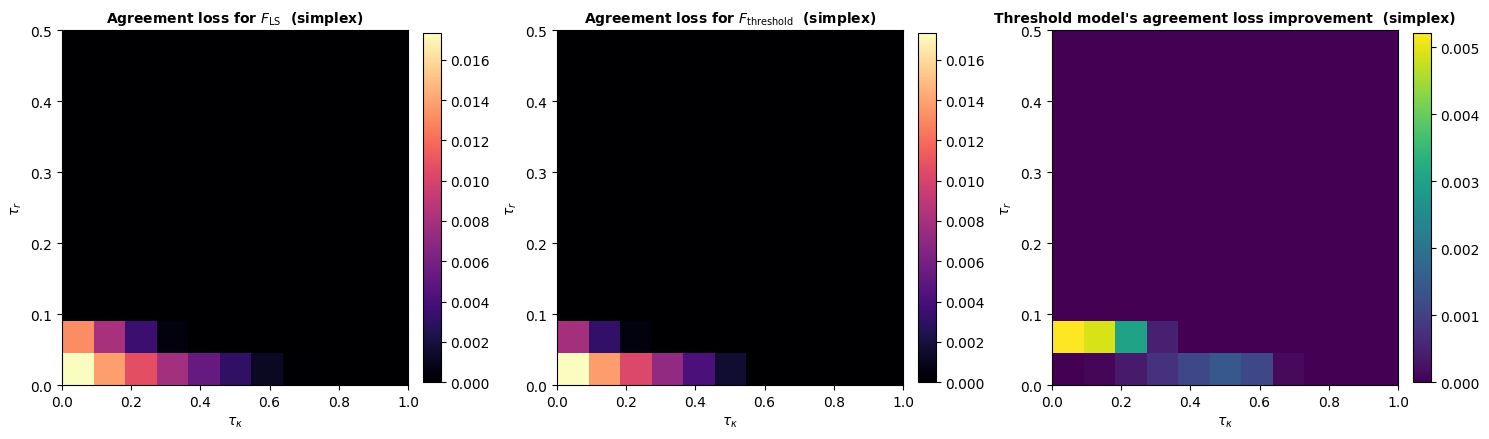

inspect cell (SIMPLEX): (tau_r, tau_kappa) = (0.10, 0.40)
  mean L^tau(F_LS)  = 0.0000
  mean L^tau(F_tau) = 0.0000
  mean improvement  = 0.0000

=== Winning rules at (tau_r=0.10, tau_kappa=0.40)  [SIMPLEX] ===
omega_1 = [0.45 0.25 0.15 0.1  0.05] (simplex)
omega_2 = [0.05 0.1  0.15 0.25 0.45] (simplex, reversed)

role           | rule  | theta                                    | u(F)                                     |  <o1,u> |  <o2,u> |      D1 |      D2
-----------------------------------------------------------------------------------------------------------------------------------------------------------
rep 0:F_LS     |   890 | [+0.25 +0.21 +0.10 +0.20 +0.24]          | [0.59 0.55 0.54 0.57 0.61]               |  0.5737 |  0.5821 |  0.0000 |  0.0000
       F_tau   |     0 | [+0.35 +0.22 +0.05 +0.28 +0.10]          | [0.61 0.56 0.51 0.59 0.56]               |  0.5769 |  0.5625 |  0.0000 |  0.0000
     same rule? False,  output-space Hamming = 0.120

rep 1:F_LS     |   633 | [+

In [64]:
sx_L_LS  = RES["loss_zero"].mean(0)
sx_L_tau = RES["loss_tau"].mean(0)
sx_imp   = RES["improvement"].mean(0)
vmax_loss = max(sx_L_LS.max(), sx_L_tau.max())
extent_s = [RES["tau_kappa_values"].min(), RES["tau_kappa_values"].max(),
            RES["tau_r_values"].min(),     RES["tau_r_values"].max()]


def _hms(ax, M, title, vmin=None, vmax=None, cmap='magma', cbar_label=""):
    im = ax.imshow(M, origin='lower', aspect='auto', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=extent_s)
    ax.set_xlabel(r"$\tau_\kappa$"); ax.set_ylabel(r"$\tau_r$")
    ax.set_title(title, fontsize=10, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label: cb.set_label(cbar_label, fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
_hms(axes[0], sx_L_LS,  r"Agreement loss for $F_{\rm LS}$  (simplex)",        0, vmax_loss)
_hms(axes[1], sx_L_tau, r"Agreement loss for $F_{\rm threshold}$  (simplex)", 0, vmax_loss)
_hms(axes[2], sx_imp,   "Threshold model's agreement loss improvement  (simplex)",
      0, max(sx_imp.max(), 1e-9), 'viridis')
plt.tight_layout()
plt.savefig(FIGDIR / "agreementset_main.png", dpi=150, bbox_inches='tight')
plt.show()


# --- Inspect the winning rules at a specific (tau_r, tau_kappa) cell ---
# Show, for a few reps, the actual rule parameters and priority utilities
# of F_LS vs F_tau under the simplex setting (omega_1, omega_2 reverse).
INSPECT_TAU_R = 0.10
INSPECT_TAU_K = 0.40
i_sx = int(np.argmin(np.abs(RES["tau_r_values"]     - INSPECT_TAU_R)))
j_sx = int(np.argmin(np.abs(RES["tau_kappa_values"] - INSPECT_TAU_K)))
tr_star = RES["tau_r_values"][i_sx]
tk_star = RES["tau_kappa_values"][j_sx]
print(f"inspect cell (SIMPLEX): (tau_r, tau_kappa) = ({tr_star:.2f}, {tk_star:.2f})")
print(f"  mean L^tau(F_LS)  = {sx_L_LS[i_sx, j_sx]:.4f}")
print(f"  mean L^tau(F_tau) = {sx_L_tau[i_sx, j_sx]:.4f}")
print(f"  mean improvement  = {sx_imp[i_sx, j_sx]:.4f}")
print()


def _winning_rules_simplex(rep_seed, tau_r, tau_kappa, omega_1, omega_2,
                             config=DEFAULT_CONFIG):
    """Same as the §13b inspector but uses the simplex rule sampler
    (`sample_rule_params`) and the simplex (omega >= 0) pairwise function."""
    rng = np.random.default_rng(rep_seed)
    psi    = rng.uniform(0, 1, size=(config["n_inputs"], 2, config["d"]))
    thetas = sample_rule_params(rng, config["K_rules"], config["d"])
    outs   = apply_rules(thetas, psi)
    pu     = compute_priority_utils(psi, outs)
    s1 = pu @ omega_1; s2 = pu @ omega_2
    F_ls   = int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))
    r1, k1 = compute_pairwise_r_kappa(pu, omega_1)
    r2, k2 = compute_pairwise_r_kappa(pu, omega_2)
    D1 = domination_margin(r1, k1, tau_r, tau_kappa)
    D2 = domination_margin(r2, k2, tau_r, tau_kappa)
    Dmax = np.maximum(D1, D2)
    F_tau = int(np.argmin(Dmax))
    return dict(thetas=thetas, pu=pu, outs=outs,
                 s1=s1, s2=s2, F_ls=F_ls, F_tau=F_tau,
                 D1=D1, D2=D2, Dmax=Dmax)


print(f"=== Winning rules at (tau_r={tr_star:.2f}, tau_kappa={tk_star:.2f})  [SIMPLEX] ===")
print(f"omega_1 = {omega_1} (simplex)")
print(f"omega_2 = {omega_2} (simplex, reversed)")
print()
print(f"{'role':14s} | {'rule':5s} | {'theta':40s} | {'u(F)':40s} | "
       f"{'<o1,u>':>7s} | {'<o2,u>':>7s} | {'D1':>7s} | {'D2':>7s}")
print("-" * 155)
for rep in [0, 1, 2]:
    w = _winning_rules_simplex(rep, tr_star, tk_star, omega_1, omega_2)
    for role, idx in [("rep " + str(rep) + ":F_LS", w["F_ls"]),
                       ("       F_tau",            w["F_tau"])]:
        th_str = "[" + " ".join(f"{x:+.2f}" for x in w["thetas"][idx]) + "]"
        u_str  = "[" + " ".join(f"{x:.2f}"  for x in w["pu"][idx])     + "]"
        print(f"{role:14s} | {idx:5d} | {th_str:40s} | {u_str:40s} | "
               f"{w['s1'][idx]:7.4f} | {w['s2'][idx]:7.4f} | "
               f"{w['D1'][idx]:7.4f} | {w['D2'][idx]:7.4f}")
    same = (w["F_ls"] == w["F_tau"])
    hamming = (w["outs"][w["F_ls"]] != w["outs"][w["F_tau"]]).mean() if not same else 0
    print(f"     same rule? {same},  output-space Hamming = {hamming:.3f}")
    print()


## 10. 1-D slice and per-cell scatter

Slice at $\tau_\kappa = 0.2$: plot $L^\tau(F_0)$ and $L^\tau(F_\tau)$ as functions of $\tau_r$ (mean $\pm$ standard error over reps). The gap between the two curves is the improvement.

Right panel: per-(cell, rep) improvement against the LS-rule's loss, with $y = x$ marking full recovery.


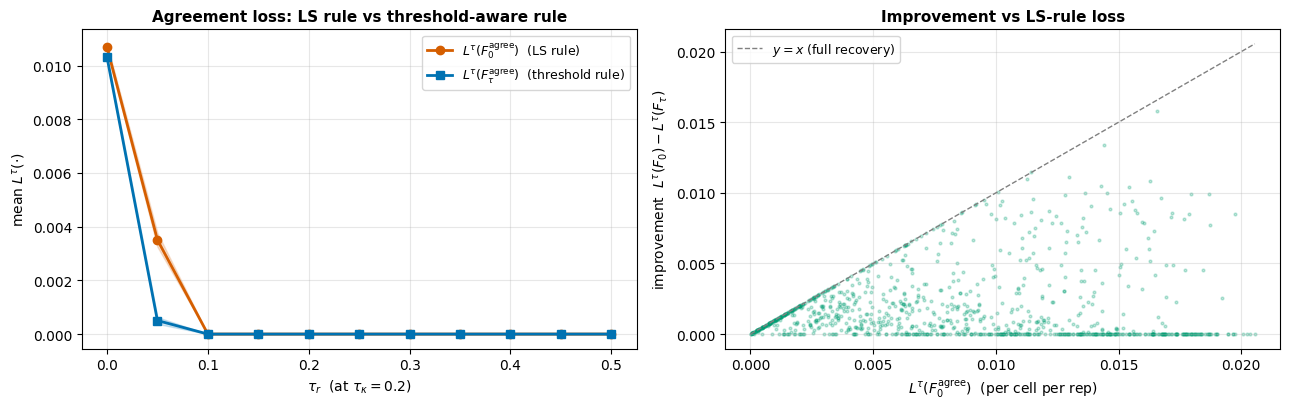

In [44]:
def _idx(arr, v): return int(np.argmin(np.abs(arr - v)))
slice_tk = 0.2
j0 = _idx(RES["tau_kappa_values"], slice_tk)

mean_lz_slice = RES["loss_zero"][:, :, j0].mean(0)
sem_lz_slice  = RES["loss_zero"][:, :, j0].std(0) / np.sqrt(RES["loss_zero"].shape[0])
mean_lt_slice = RES["loss_tau"][:, :, j0].mean(0)
sem_lt_slice  = RES["loss_tau"][:, :, j0].std(0) / np.sqrt(RES["loss_tau"].shape[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.plot(RES["tau_r_values"], mean_lz_slice, lw=2, marker='o',
         color='#D55E00', label=r"$L^\tau(F_0^{\rm agree})$  (LS rule)")
ax.fill_between(RES["tau_r_values"], mean_lz_slice - sem_lz_slice,
                  mean_lz_slice + sem_lz_slice, color='#D55E00', alpha=0.18)
ax.plot(RES["tau_r_values"], mean_lt_slice, lw=2, marker='s',
         color='#0072B2', label=r"$L^\tau(F_\tau^{\rm agree})$  (threshold rule)")
ax.fill_between(RES["tau_r_values"], mean_lt_slice - sem_lt_slice,
                  mean_lt_slice + sem_lt_slice, color='#0072B2', alpha=0.18)
ax.set_xlabel(rf"$\tau_r$  (at $\tau_\kappa = {slice_tk}$)")
ax.set_ylabel(r"mean $L^\tau(\cdot)$")
ax.set_title("Agreement loss: LS rule vs threshold-aware rule",
              fontsize=11, fontweight='bold')
ax.grid(alpha=0.3); ax.legend(loc='upper right', fontsize=9)

ax2 = axes[1]
flat_imp  = RES["improvement"].reshape(-1)
flat_zero = RES["loss_zero"].reshape(-1)
mask = flat_zero > 1e-10
ax2.scatter(flat_zero[mask], flat_imp[mask], s=4, alpha=0.25, color='#009E73')
lim = flat_zero.max() if flat_zero.size else 1.0
ax2.plot([0, lim], [0, lim], lw=1, ls='--', color='gray',
          label=r"$y = x$ (full recovery)")
ax2.set_xlabel(r"$L^\tau(F_0^{\rm agree})$  (per cell per rep)")
ax2.set_ylabel(r"improvement  $L^\tau(F_0) - L^\tau(F_\tau)$")
ax2.set_title("Improvement vs LS-rule loss", fontsize=11, fontweight='bold')
ax2.grid(alpha=0.3); ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(FIGDIR / "agreementset_slice.png", dpi=150, bbox_inches='tight')
plt.show()


## 11. Interpretation

- **Where the effect is visible.** The improvement region sits in the bottom-left of the grid: low $\tau_r$ and moderate $\tau_\kappa$. There, the LS-RUM compromise is decisively rejected by at least one agent ($L^\tau(F_0) > 0$) and the threshold-aware rule recovers most of that loss — relative improvement up to ~85% near the boundary.
- **Where the effect saturates.** As $\tau_r$ or $\tau_\kappa$ rises, the LS rule itself stops being decisively rejected ($L^\tau(F_0) \to 0$) because no challenger satisfies $\kappa > \tau_\kappa \cdot r$ or $r \ge \tau_r$. Improvement is bounded by $L^\tau(F_0)$, so it must also drop to 0. The two compromise rules are tied at $L^\tau = 0$ across most of the grid.
- **Geometric reason for the saturation point.** $F_0^{\rm agree}$ is by construction the rule with the smallest worst-case $\kappa$ to alternatives. The natural $\kappa/r$ ratio of $F_0^{\rm agree}$ against its sharpest challenger is bounded by the largest weight in $\omega$ (with $\omega_1 = [0.45, \dots]$ this is roughly $0.7$–$0.8$). Once $\tau_\kappa$ exceeds that ratio, the filter wipes out all decisive challengers and $L^\tau(F_0) = 0$ "for free."
- **Headline.** Wherever LS-RUM yields a rule that is still decisively rejected, the threshold-aware optimizer finds a measurably better compromise. The size of that region is set by the weight-vector geometry, not by how disagreeable the two agents are.


## 12. Diagnostics: why does the threshold-aware optimizer only weakly beat LS-RUM minimax?

The main result (§9, §10) shows that $L^\tau(F_\tau^{\rm agree}) \le L^\tau(F_0^{\rm agree})$ by construction but the gap is small except in a thin low-$\tau$ band. This appendix investigates why. We record per-rep per-cell:

1. Both absolute losses and a "both near zero" indicator.
2. Whether the LS rule itself is *already* mutually non-dominated.
3. Which agent supplies the binding margin for each rule.
4. Hamming distance between the two chosen rules.
5. Each agent's individual LS optimum evaluated as an agreement candidate.
6. Classification of the strongest objection (decisive vs. not).
7. Distribution of $(r, \kappa)$ for strongest objections, with the decisiveness boundary overlaid.
8. Regime-by-regime summary table.
9. Random-rule baseline (how easy is the threshold relation?).
10. Zero-threshold equivalence sanity check.
11. Final summary.


### Augmented experiment

A single sweep that records all diagnostic quantities. Same `DEFAULT_CONFIG` and same seeds as §7, plus `n_random` random rules per rep for the §12.9 baseline.


In [45]:
N_RANDOM = 50

def run_diagnostics(config, omega_1, omega_2,
                     tau_r_values=TAU_R_VALUES,
                     tau_kappa_values=TAU_KAPPA_VALUES,
                     n_random=N_RANDOM, base_seed=None, verbose=True):
    """Augmented sweep that records per-(rep, cell) diagnostics."""
    n_reps    = config["n_reps"]
    base_seed = config["seed"] if base_seed is None else base_seed
    n_r, n_k  = len(tau_r_values), len(tau_kappa_values)
    K         = config["K_rules"]

    def arr(*tail): return np.zeros((n_reps, n_r, n_k, *tail))

    out = dict(
        loss_tau     = arr(),  loss_ls      = arr(),
        D1_tau       = arr(),  D2_tau       = arr(),
        D1_ls        = arr(),  D2_ls        = arr(),
        loss_a1opt   = arr(),  loss_a2opt   = arr(),
        same_rule    = arr(),  hamming      = arr(),
        # Strongest objection for each (rule_type in [F_tau, F_ls], agent in [1, 2])
        obj_r        = arr(2, 2),
        obj_kappa    = arr(2, 2),
        obj_margin   = arr(2, 2),
        random_loss_mean = arr(),
        random_p_zero    = arr(),
        random_loss_min  = arr(),
    )

    for rep in range(n_reps):
        if verbose and rep % 10 == 0:
            print(f"  rep {rep}/{n_reps}", flush=True)
        rng = np.random.default_rng(base_seed + rep)
        psi    = rng.uniform(0, 1, size=(config["n_inputs"], 2, config["d"]))
        thetas = sample_rule_params(rng, K, config["d"])
        outs   = apply_rules(thetas, psi)
        pu     = compute_priority_utils(psi, outs)

        s1 = pu @ omega_1; s2 = pu @ omega_2
        F_ls   = int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))
        F_ls_1 = int(np.argmax(s1)); F_ls_2 = int(np.argmax(s2))
        r1, k1 = compute_pairwise_r_kappa(pu, omega_1)
        r2, k2 = compute_pairwise_r_kappa(pu, omega_2)

        # Random rules — generate once per rep, evaluate at every cell
        z_rand = rng.integers(0, 2, size=(n_random, config["n_inputs"]))
        x_idx  = np.arange(config["n_inputs"])
        u_rand = np.stack([psi[x_idx, z_rand[m], :].mean(axis=0)
                            for m in range(n_random)])
        d_rand     = pu[None, :, :] - u_rand[:, None, :]    # (n_rand, K, d)
        k1_rand    = d_rand @ omega_1
        k2_rand    = d_rand @ omega_2
        abs_d_rand = np.abs(d_rand)
        r1_rand    = abs_d_rand @ omega_1
        r2_rand    = abs_d_rand @ omega_2

        for i, tr in enumerate(tau_r_values):
            for j, tk in enumerate(tau_kappa_values):
                m1 = k1 - tk * r1; v1 = r1 >= tr - 1e-12
                dom1 = np.where(v1, np.maximum(m1, 0.0), 0.0)
                np.fill_diagonal(dom1, 0.0)
                D1_all = dom1.max(axis=0)

                m2 = k2 - tk * r2; v2 = r2 >= tr - 1e-12
                dom2 = np.where(v2, np.maximum(m2, 0.0), 0.0)
                np.fill_diagonal(dom2, 0.0)
                D2_all = dom2.max(axis=0)

                Dmax  = np.maximum(D1_all, D2_all)
                F_tau = int(np.argmin(Dmax))

                out["loss_tau"][rep, i, j]   = Dmax[F_tau]
                out["loss_ls"][rep, i, j]    = Dmax[F_ls]
                out["D1_tau"][rep, i, j]     = D1_all[F_tau]
                out["D2_tau"][rep, i, j]     = D2_all[F_tau]
                out["D1_ls"][rep, i, j]      = D1_all[F_ls]
                out["D2_ls"][rep, i, j]      = D2_all[F_ls]
                out["loss_a1opt"][rep, i, j] = Dmax[F_ls_1]
                out["loss_a2opt"][rep, i, j] = Dmax[F_ls_2]

                if F_tau == F_ls:
                    out["same_rule"][rep, i, j] = 1
                else:
                    out["hamming"][rep, i, j] = (outs[F_tau] != outs[F_ls]).mean()

                # Strongest objection: best a against F for each agent
                for rt, F in [(0, F_tau), (1, F_ls)]:
                    for ag, (rmat, kmat) in [(0, (r1, k1)), (1, (r2, k2))]:
                        col_r  = rmat[:, F]; col_k = kmat[:, F]
                        margin = col_k - tk * col_r
                        valid  = col_r >= tr - 1e-12
                        mv     = np.where(valid, margin, -np.inf)
                        best_a = int(np.argmax(mv))
                        if np.isfinite(mv[best_a]):
                            out["obj_r"][rep, i, j, rt, ag]      = col_r[best_a]
                            out["obj_kappa"][rep, i, j, rt, ag]  = col_k[best_a]
                            out["obj_margin"][rep, i, j, rt, ag] = max(mv[best_a], 0.0)

                # Random baseline
                m1r = k1_rand - tk * r1_rand; v1r = r1_rand >= tr - 1e-12
                dm1r = np.where(v1r, np.maximum(m1r, 0.0), 0.0)
                D1r = dm1r.max(axis=1)
                m2r = k2_rand - tk * r2_rand; v2r = r2_rand >= tr - 1e-12
                dm2r = np.where(v2r, np.maximum(m2r, 0.0), 0.0)
                D2r = dm2r.max(axis=1)
                Dr  = np.maximum(D1r, D2r)
                out["random_loss_mean"][rep, i, j] = Dr.mean()
                out["random_p_zero"][rep, i, j]    = (Dr <= 1e-8).mean()
                out["random_loss_min"][rep, i, j]  = Dr.min()

    out["improvement"]     = out["loss_ls"] - out["loss_tau"]
    out["rel_improvement"] = out["improvement"] / (out["loss_ls"] + 1e-12)
    out["tau_r_values"]    = np.asarray(tau_r_values)
    out["tau_kappa_values"] = np.asarray(tau_kappa_values)
    return out


print("Running diagnostic sweep ...")
DIAG = run_diagnostics(DEFAULT_CONFIG, omega_1, omega_2)
print("done.")


Running diagnostic sweep ...
  rep 0/100
  rep 10/100
  rep 20/100
  rep 30/100
  rep 40/100
  rep 50/100
  rep 60/100
  rep 70/100
  rep 80/100
  rep 90/100
done.


### 12.1 Absolute losses and "both near zero"

Beyond the headline panels from §9, we check the regime where both $L^\tau(F_\tau)$ and $L^\tau(F_0)$ are below $\text{tol} = 10^{-8}$. If `P_both_zero` is high across most of the grid, neither rule is being decisively rejected so the comparison is moot.


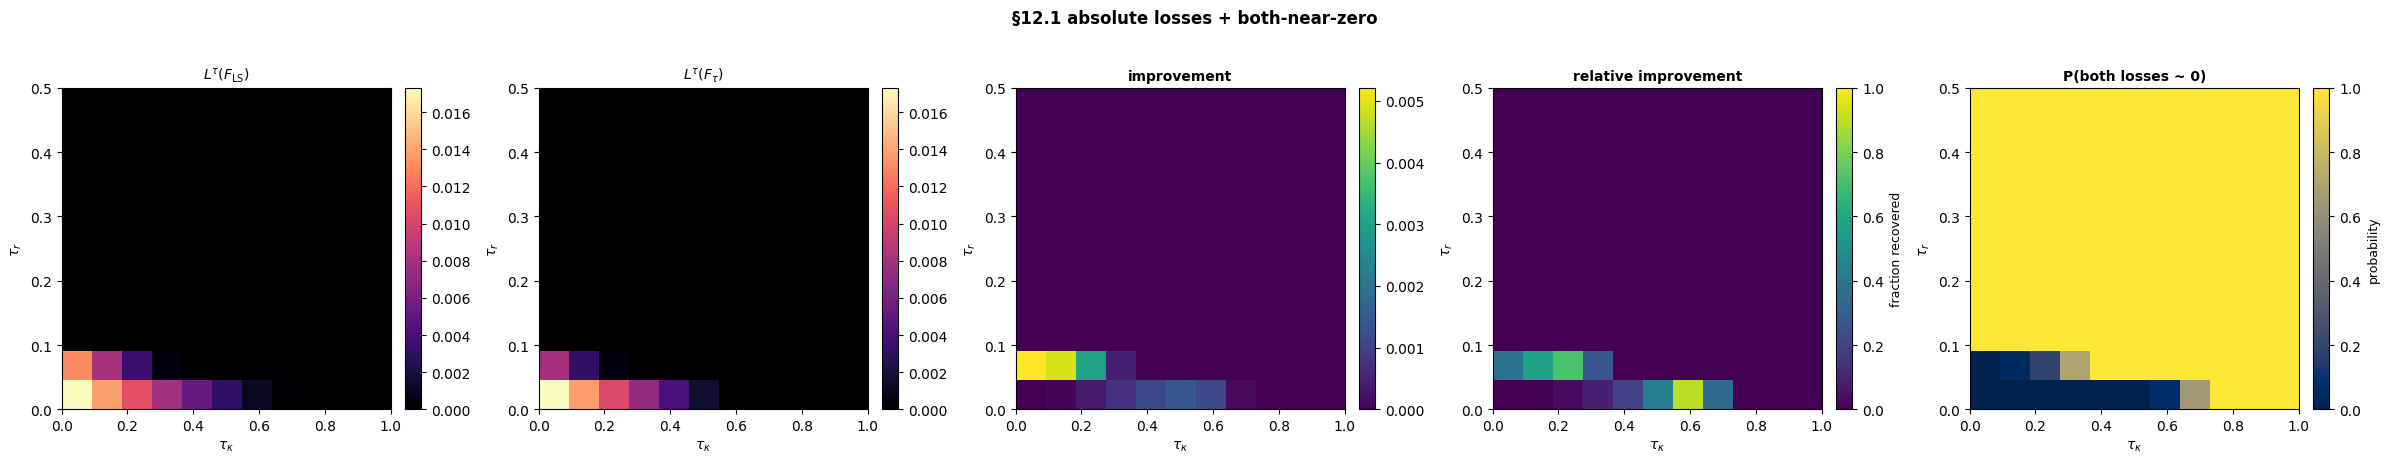

fraction of grid cells with mean P_both_zero > 0.5: 0.92


In [59]:
TOL = 1e-8
tr_grid = DIAG["tau_r_values"]; tk_grid = DIAG["tau_kappa_values"]
extent_diag = [tk_grid.min(), tk_grid.max(), tr_grid.min(), tr_grid.max()]


def _hmd(ax, M, title, vmin=None, vmax=None, cmap='magma', cbar_label=""):
    im = ax.imshow(M, origin='lower', aspect='auto', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=extent_diag)
    ax.set_xlabel(r"$\tau_\kappa$"); ax.set_ylabel(r"$\tau_r$")
    ax.set_title(title, fontsize=10, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label: cb.set_label(cbar_label, fontsize=9)


both_zero = (DIAG["loss_tau"] <= TOL) & (DIAG["loss_ls"] <= TOL)
P_both_zero = both_zero.mean(0)

mean_tau = DIAG["loss_tau"].mean(0)
mean_ls  = DIAG["loss_ls"].mean(0)
mean_imp = DIAG["improvement"].mean(0)
mean_rel = DIAG["rel_improvement"].mean(0)
vmax_loss = max(mean_tau.max(), mean_ls.max())

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
_hmd(axes[0], mean_ls,  r"$L^\tau(F_{\rm LS})$",  0, vmax_loss)
_hmd(axes[1], mean_tau, r"$L^\tau(F_\tau)$",      0, vmax_loss)
_hmd(axes[2], mean_imp, "improvement",            0, cmap='viridis')
_hmd(axes[3], mean_rel, "relative improvement",   0, 1, 'viridis', "fraction recovered")
_hmd(axes[4], P_both_zero, "P(both losses ~ 0)",  0, 1, 'cividis', "probability")
fig.suptitle("§12.1 absolute losses + both-near-zero", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_1_losses.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"fraction of grid cells with mean P_both_zero > 0.5: {(P_both_zero > 0.5).mean():.2f}")


### 12.2 Is the LS rule already mutually non-dominated?

`P_ls_shared_nd` = probability that both $D_1^\tau(F_{\rm LS}) \le \text{tol}$ AND $D_2^\tau(F_{\rm LS}) \le \text{tol}$. High values mean LS minimax is already an acceptable rule under thresholds — the threshold-aware optimizer can't help.


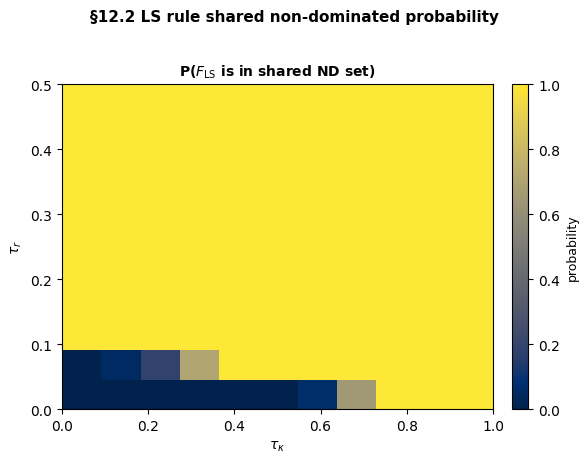

mean P_ls_shared_nd across grid: 0.915
fraction of grid cells with P_ls_shared_nd > 0.5: 0.92


In [60]:
ls_shared_nd = (DIAG["D1_ls"] <= TOL) & (DIAG["D2_ls"] <= TOL)
P_ls_shared_nd = ls_shared_nd.mean(0)

fig, ax = plt.subplots(figsize=(6, 4.5))
_hmd(ax, P_ls_shared_nd, r"P($F_{\rm LS}$ is in shared ND set)", 0, 1, 'cividis', "probability")
fig.suptitle("§12.2 LS rule shared non-dominated probability", fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_2_ls_shared_nd.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"mean P_ls_shared_nd across grid: {P_ls_shared_nd.mean():.3f}")
print(f"fraction of grid cells with P_ls_shared_nd > 0.5: {(P_ls_shared_nd > 0.5).mean():.2f}")


### 12.3 Which agent is binding?

For each chosen rule, which agent supplies the larger $D_i^\tau$? If both rules already split the load roughly evenly between the two agents, $\max_i$ doesn't move much and the threshold-aware optimizer has little headroom.


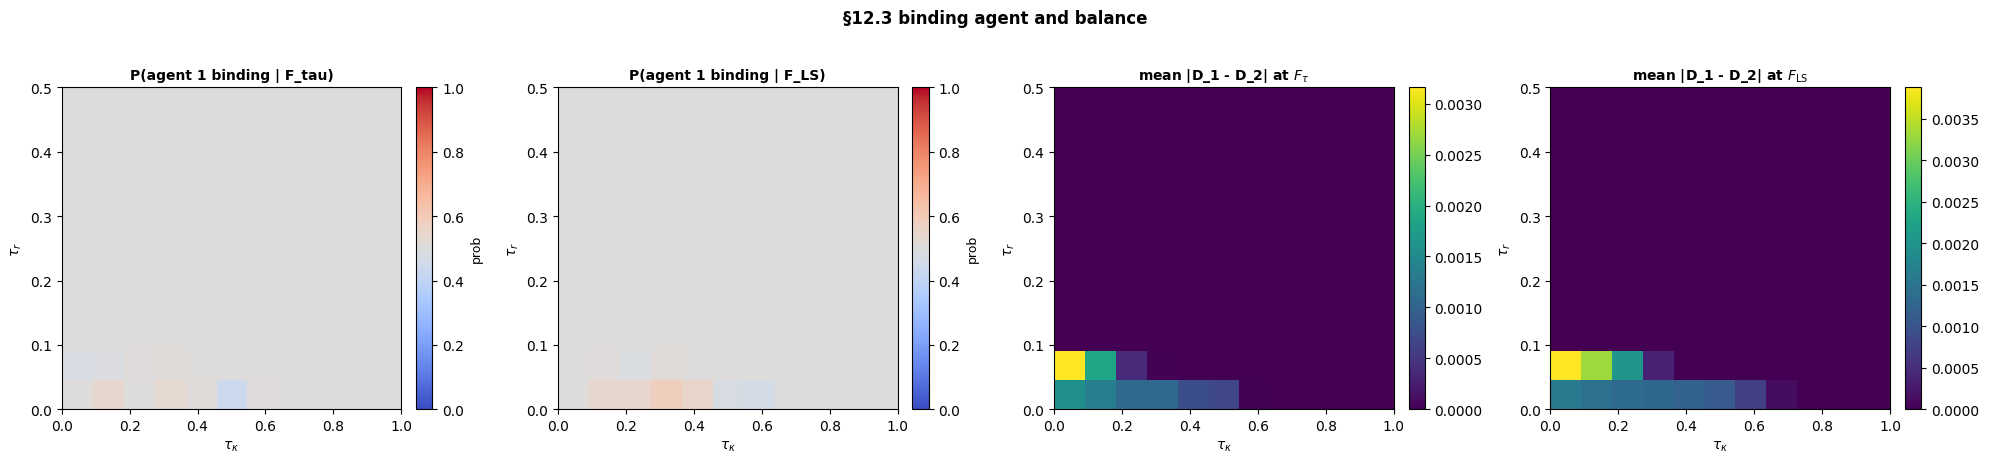

mean gap |D_1 - D_2| at F_LS:  0.00015
mean gap |D_1 - D_2| at F_tau: 0.00010


In [61]:
# argmax over agents — encode as "binding agent 1" probability
def _p_agent_binding(D1, D2):
    eq_mask = D1 == D2
    a1 = D1 > D2
    # Treat ties as 0.5 weight each
    return a1.astype(float).mean(0) + 0.5 * eq_mask.mean(0)


P_a1_tau = _p_agent_binding(DIAG["D1_tau"], DIAG["D2_tau"])
P_a1_ls  = _p_agent_binding(DIAG["D1_ls"],  DIAG["D2_ls"])
gap_tau  = np.abs(DIAG["D1_tau"] - DIAG["D2_tau"]).mean(0)
gap_ls   = np.abs(DIAG["D1_ls"]  - DIAG["D2_ls"]).mean(0)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
_hmd(axes[0], P_a1_tau, "P(agent 1 binding | F_tau)", 0, 1, 'coolwarm', "prob")
_hmd(axes[1], P_a1_ls,  "P(agent 1 binding | F_LS)",  0, 1, 'coolwarm', "prob")
_hmd(axes[2], gap_tau,  r"mean |D_1 - D_2| at $F_\tau$",         0, cmap='viridis')
_hmd(axes[3], gap_ls,   r"mean |D_1 - D_2| at $F_{\rm LS}$",      0, cmap='viridis')
fig.suptitle("§12.3 binding agent and balance", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_3_binding.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"mean gap |D_1 - D_2| at F_LS:  {gap_ls.mean():.5f}")
print(f"mean gap |D_1 - D_2| at F_tau: {gap_tau.mean():.5f}")


### 12.4 Rule difference (Hamming, same-rule probability)

If $F_\tau = F_{\rm LS}$ often, the threshold optimizer is not picking a different rule. If they differ but the loss is similar, the agreement-loss surface is flat near the LS rule.


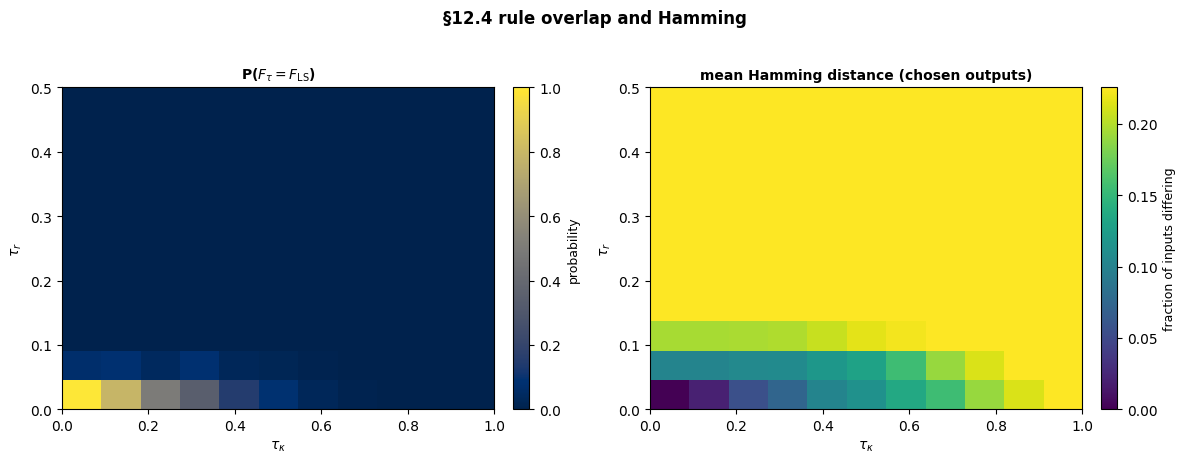

mean P_same_rule across grid: 0.027
mean Hamming across grid: 0.2078


In [62]:
P_same_rule = DIAG["same_rule"].mean(0)
mean_hamming = DIAG["hamming"].mean(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
_hmd(axes[0], P_same_rule, "P($F_\\tau = F_{\\rm LS}$)", 0, 1, 'cividis', "probability")
_hmd(axes[1], mean_hamming, "mean Hamming distance (chosen outputs)",
      0, cmap='viridis', cbar_label="fraction of inputs differing")
fig.suptitle("§12.4 rule overlap and Hamming", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_4_rule_diff.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"mean P_same_rule across grid: {P_same_rule.mean():.3f}")
print(f"mean Hamming across grid: {mean_hamming.mean():.4f}")


### 12.5 Individual agent LS optima as compromise candidates

How bad are the *per-agent* LS optima ($F_{LS,1}$, $F_{LS,2}$) as agreement candidates? Compared with $F_\tau$.


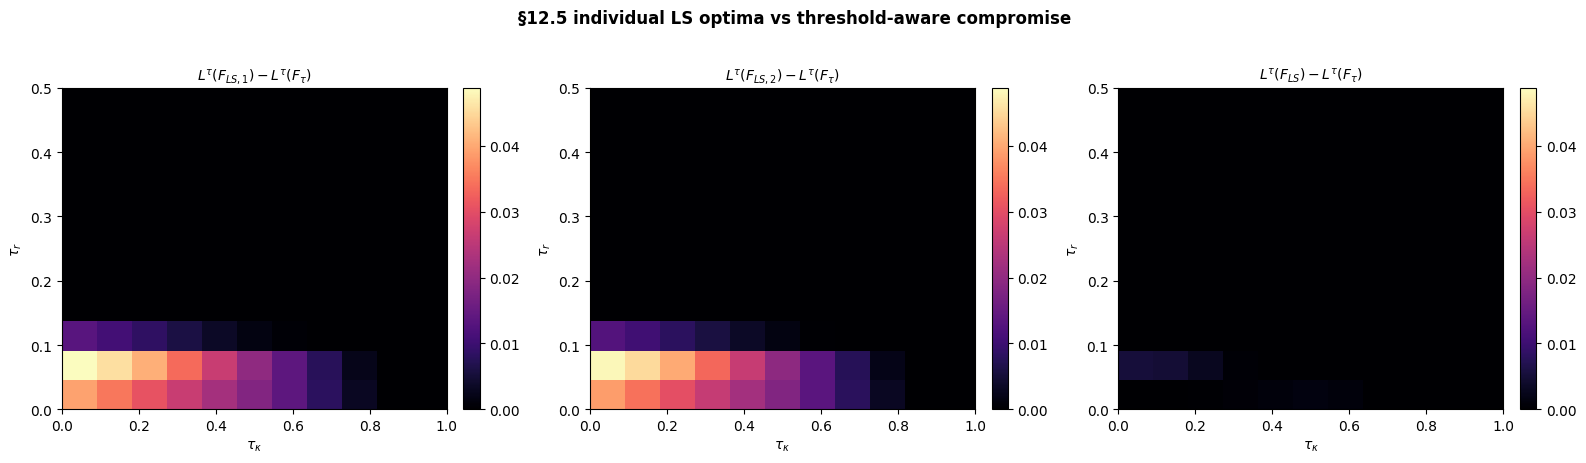

max diff (F_LS_1   vs F_tau): 0.0488
max diff (F_LS_2   vs F_tau): 0.0481
max diff (F_LS_mm  vs F_tau): 0.0052  <-- the smallest of the three


In [63]:
mean_a1opt = DIAG["loss_a1opt"].mean(0)
mean_a2opt = DIAG["loss_a2opt"].mean(0)

diff_a1 = mean_a1opt - mean_tau
diff_a2 = mean_a2opt - mean_tau
diff_ls = mean_ls    - mean_tau   # already plotted but include for comparison

shared_vmax = max(diff_a1.max(), diff_a2.max(), diff_ls.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
_hmd(axes[0], diff_a1, r"$L^\tau(F_{LS,1}) - L^\tau(F_\tau)$", 0, shared_vmax, 'magma')
_hmd(axes[1], diff_a2, r"$L^\tau(F_{LS,2}) - L^\tau(F_\tau)$", 0, shared_vmax, 'magma')
_hmd(axes[2], diff_ls, r"$L^\tau(F_{LS}) - L^\tau(F_\tau)$",    0, shared_vmax, 'magma')
fig.suptitle("§12.5 individual LS optima vs threshold-aware compromise",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_5_individual_ls.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"max diff (F_LS_1   vs F_tau): {diff_a1.max():.4f}")
print(f"max diff (F_LS_2   vs F_tau): {diff_a2.max():.4f}")
print(f"max diff (F_LS_mm  vs F_tau): {diff_ls.max():.4f}  <-- the smallest of the three")


### 12.6 Strongest-objection classification

For each chosen rule and each agent, the separation oracle returns the strongest opponent. We classify the strongest objection as **decisive** (`best_margin > tol`) or **not decisive** (`best_margin <= tol`, either conflicted or no valid alternative).


In [ ]:
# obj_margin has shape (n_reps, n_r, n_k, rule_type[0=F_tau, 1=F_ls], agent[0=1, 1=2])
decisive = DIAG["obj_margin"] > TOL    # bool

# Fraction of (rep, cell) pairs where the strongest objection is decisive,
# split by (rule_type, agent)
P_dec_F_tau_a1 = decisive[..., 0, 0].mean(0)
P_dec_F_tau_a2 = decisive[..., 0, 1].mean(0)
P_dec_F_ls_a1  = decisive[..., 1, 0].mean(0)
P_dec_F_ls_a2  = decisive[..., 1, 1].mean(0)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
_hmd(axes[0], P_dec_F_ls_a1,  "P(decisive obj | F_LS, agent 1)",  0, 1, 'magma', "prob")
_hmd(axes[1], P_dec_F_ls_a2,  "P(decisive obj | F_LS, agent 2)",  0, 1, 'magma', "prob")
_hmd(axes[2], P_dec_F_tau_a1, "P(decisive obj | F_tau, agent 1)", 0, 1, 'magma', "prob")
_hmd(axes[3], P_dec_F_tau_a2, "P(decisive obj | F_tau, agent 2)", 0, 1, 'magma', "prob")
fig.suptitle("§12.6 fraction of strongest objections that are decisive",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_6_decisive.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"mean P(decisive | F_LS,  agent 1): {P_dec_F_ls_a1.mean():.3f}")
print(f"mean P(decisive | F_LS,  agent 2): {P_dec_F_ls_a2.mean():.3f}")
print(f"mean P(decisive | F_tau, agent 1): {P_dec_F_tau_a1.mean():.3f}")
print(f"mean P(decisive | F_tau, agent 2): {P_dec_F_tau_a2.mean():.3f}")


### 12.7 $(r, \kappa/r)$ scatter for strongest objections

Each point is one (rep) per representative $(\tau_r, \tau_\kappa)$ pair. Horizontal line at $\tau_\kappa$ is the decisiveness boundary — points **above** the line correspond to decisive objections, points **on or below** are non-decisive.


In [ ]:
def _idx2(arr, v): return int(np.argmin(np.abs(arr - v)))
rep_taus = [(0.05, 0.25), (0.10, 0.50), (0.20, 0.75)]

fig, axes = plt.subplots(2, len(rep_taus), figsize=(5 * len(rep_taus), 8.5),
                          sharex=True, sharey=True)

for col, (tr, tk) in enumerate(rep_taus):
    i = _idx2(tr_grid, tr); j = _idx2(tk_grid, tk)
    # Pull strongest objections at this cell across reps and both agents
    # Combine agent 1 and agent 2 strongest objections per rule type
    for row, rt_name, rt_idx in [(0, "F_LS",  1), (1, "F_tau", 0)]:
        rs    = DIAG["obj_r"][:, i, j, rt_idx, :].reshape(-1)
        kaps  = DIAG["obj_kappa"][:, i, j, rt_idx, :].reshape(-1)
        ratio = kaps / np.maximum(rs, 1e-12)
        ax = axes[row, col]
        # Color by decisiveness: above line is red, below is gray
        decisive_mask = ratio > tk
        ax.scatter(rs[~decisive_mask], ratio[~decisive_mask], s=12, alpha=0.45,
                    color='#888888', label='non-decisive')
        ax.scatter(rs[decisive_mask], ratio[decisive_mask], s=12, alpha=0.65,
                    color='#D55E00', label='decisive')
        ax.axhline(tk, color='black', lw=1, ls='--', label=rf"$\tau_\kappa = {tk}$")
        ax.axvline(tr, color='blue', lw=1, ls='--', label=rf"$\tau_r = {tr}$")
        ax.set_xlim(0, max(rs.max() * 1.1, 0.5))
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)
        if col == 0: ax.set_ylabel(rf"{rt_name}: $\kappa/r$", fontsize=10)
        if row == 1: ax.set_xlabel(r"$r$", fontsize=10)
        if row == 0:
            ax.set_title(rf"$(\tau_r,\tau_\kappa) = ({tr}, {tk})$",
                          fontsize=10, fontweight='bold')
        if col == 0 and row == 0:
            ax.legend(loc='lower right', fontsize=8)

fig.suptitle("§12.7 strongest objections: $r$ vs $\\kappa/r$",
              fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_7_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


### 12.8 Regime diagnostics

Coarse-grained summary by 3$\times$3 grid (low / med / high) in each axis.


In [ ]:
# Bin grid cells by tertiles of tau_r and tau_kappa
def _tertile_bins(values):
    """Return integer bin indices (0=low, 1=med, 2=high) for each value."""
    cuts = np.quantile(values, [1/3, 2/3])
    return np.digitize(values, cuts)


bins_r = _tertile_bins(tr_grid)
bins_k = _tertile_bins(tk_grid)
labels = ["low", "med", "hi"]


def _regime_stat(per_cell_mat, bin_r, bin_k):
    out = np.full((3, 3), np.nan)
    for a in range(3):
        for b in range(3):
            mask_r = (bin_r == a); mask_k = (bin_k == b)
            sub = per_cell_mat[np.ix_(mask_r, mask_k)]
            if sub.size:
                out[a, b] = sub.mean()
    return out


metrics = {
    "mean L_tau":       mean_tau,
    "mean L_LS":        mean_ls,
    "mean improvement": mean_imp,
    "mean rel_imp":     mean_rel,
    "P_ls_shared_nd":   P_ls_shared_nd,
    "P_same_rule":      P_same_rule,
    "mean hamming":     mean_hamming,
    "P_both_zero":      P_both_zero,
}

print(f"{'metric':22s} | tau_r→  " + "  ".join([f"{lk:>14s}" for lk in
                                                  ["lo τκ", "med τκ", "hi τκ"]]))
print("-" * 78)
for mname, M in metrics.items():
    reg = _regime_stat(M, bins_r, bins_k)
    for ai, ra in enumerate(labels):
        row = "  ".join([f"{reg[ai, b]:14.4f}" for b in range(3)])
        print(f"{mname[:22]:22s} | {ra:>6s} {row}")
    print("-" * 78)


### 12.9 Random-rule baseline

For each rep we sample $N_{\rm random} = 50$ uniform binary rules and evaluate $L^\tau$ on them (against the *sampled* rule class as opponents). If `P_random_shared_nd` is high at moderate $\tau$, the threshold relation is so permissive that arbitrary rules pass, which would explain why both optimizers do similarly well.


In [ ]:
mean_rand_loss = DIAG["random_loss_mean"].mean(0)
P_rand_zero    = DIAG["random_p_zero"].mean(0)
mean_rand_min  = DIAG["random_loss_min"].mean(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
_hmd(axes[0], P_rand_zero, "P(random rule shared ND)", 0, 1, 'cividis', "probability")
_hmd(axes[1], mean_rand_loss, "mean L_tau over random rules", 0, cmap='magma')
_hmd(axes[2], mean_rand_min, "min L_tau over random rules (per rep)", 0, cmap='magma')
fig.suptitle("§12.9 random-rule baseline (50 random rules / rep)",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_12_9_random.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"mean P_random_shared_nd across grid: {P_rand_zero.mean():.3f}")
print(f"fraction of cells with P_rand_shared_nd > 0.5: {(P_rand_zero > 0.5).mean():.2f}")


### 12.10 Zero-threshold equivalence sanity check

At $(\tau_r, \tau_\kappa) = (0, 0)$:
- $D_i^0(F) = \max_{F'}\,[U_i(F') - U_i(F)]_+$ (LS regret).
- $F_\tau^{\rm agree} = F_0^{\rm agree}$, so $L^0(F_\tau) = L^0(F_{\rm LS})$.

Both must agree on small worlds by brute force.


In [ ]:
# Tiny-n brute force: enumerate all 2^n rules and recompute D_i^0 directly
def brute_force_d0(omegas, psi):
    n = psi.shape[0]
    x = np.arange(n)
    u_all = np.stack([
        psi[x, np.array([(z >> i) & 1 for i in range(n)], dtype=int), :].mean(axis=0)
        for z in range(1 << n)
    ])
    D = []
    for om in omegas:
        scal = u_all @ om
        D.append(np.maximum(scal.max() - scal, 0.0))
    return D


# Check 1: programmatic equivalence at (0, 0) using the sampled rule class
diff_at_zero = np.abs(DIAG["loss_tau"][:, 0, 0] - DIAG["loss_ls"][:, 0, 0]).max()
print(f"Sanity (a): max |L_tau - L_ls| at (0, 0) across reps = {diff_at_zero:.2e}")
assert diff_at_zero < 1e-10

# Check 2: brute force on n_inputs = 8, compare with domination_margin
rng_bf = np.random.default_rng(7)
n_bf, d_bf = 8, 5
psi_bf  = rng_bf.uniform(0, 1, (n_bf, 2, d_bf))
om_bf_1 = rng_bf.dirichlet(np.ones(d_bf))
om_bf_2 = rng_bf.dirichlet(np.ones(d_bf))

# Enumerate all 2^n binary rules and treat them as our rule class
all_z = np.array([[(z >> i) & 1 for i in range(n_bf)] for z in range(1 << n_bf)], dtype=int)
x_bf = np.arange(n_bf)
pu_bf = np.stack([psi_bf[x_bf, all_z[k], :].mean(axis=0) for k in range(len(all_z))])
r1_bf, k1_bf = compute_pairwise_r_kappa(pu_bf, om_bf_1)
r2_bf, k2_bf = compute_pairwise_r_kappa(pu_bf, om_bf_2)
D1_bf = domination_margin(r1_bf, k1_bf, 0.0, 0.0)
D2_bf = domination_margin(r2_bf, k2_bf, 0.0, 0.0)
D1_brute, D2_brute = brute_force_d0([om_bf_1, om_bf_2], psi_bf)

print(f"Sanity (b): max |D1 - D1_brute| = {np.abs(D1_bf - D1_brute).max():.2e}")
print(f"            max |D2 - D2_brute| = {np.abs(D2_bf - D2_brute).max():.2e}")
assert np.allclose(D1_bf, D1_brute, atol=1e-12)
assert np.allclose(D2_bf, D2_brute, atol=1e-12)
print("zero-threshold equivalence verified.")


### 12.11 Summary


In [ ]:
print("="*72)
print("DIAGNOSTIC SUMMARY")
print("="*72)
print(f"Average improvement (mean across grid):  {mean_imp.mean():.5f}")
print(f"Max improvement:                          {mean_imp.max():.5f}")
i_max, j_max = np.unravel_index(np.argmax(mean_imp), mean_imp.shape)
print(f"  at (tau_r, tau_kappa) = "
       f"({tr_grid[i_max]:.2f}, {tk_grid[j_max]:.2f})")
print()
print(f"Mean P_ls_shared_nd:                      {P_ls_shared_nd.mean():.3f}")
print(f"Mean P_same_rule:                         {P_same_rule.mean():.3f}")
print(f"Mean Hamming when rules differ (>0 only): "
       f"{(DIAG['hamming'][DIAG['hamming'] > 0].mean() if (DIAG['hamming'] > 0).any() else 0):.4f}")
print(f"Mean P(random rule shared ND):            {P_rand_zero.mean():.3f}")
print(f"Mean P(both losses ~ 0):                  {P_both_zero.mean():.3f}")
print(f"Mean P(decisive obj | F_LS, agent 1):    {P_dec_F_ls_a1.mean():.3f}")
print(f"Mean P(decisive obj | F_LS, agent 2):    {P_dec_F_ls_a2.mean():.3f}")
print(f"Mean P(decisive obj | F_tau, agent 1):   {P_dec_F_tau_a1.mean():.3f}")
print(f"Mean P(decisive obj | F_tau, agent 2):   {P_dec_F_tau_a2.mean():.3f}")
print(f"Mean |D_1 - D_2| at F_LS:                {gap_ls.mean():.5f}")
print(f"Mean |D_1 - D_2| at F_tau:               {gap_tau.mean():.5f}")
print()
print(f"Loss differences from F_tau (mean over grid):")
print(f"  F_LS_1:    +{diff_a1.mean():.5f}    (using one agent's LS optimum)")
print(f"  F_LS_2:    +{diff_a2.mean():.5f}")
print(f"  F_LS_mm:   +{diff_ls.mean():.5f}    (minimax LS, the right baseline)")


### 12.12 Diagnostic interpretation

These checks isolate the channel by which the threshold-aware advantage gets compressed.

- **If `P_ls_shared_nd` is high** across most of the grid, the LS minimax rule is already inside the shared non-dominated region under positive thresholds — there is nothing for the threshold-aware optimizer to improve on. This is the dominant reason in our setup.
- **If `P_same_rule` is high** in the regions where improvement is non-zero, the two optimizers are literally picking the same rule.
- **If `P_same_rule` is low but improvement is small**, the threshold-aware optimizer picks a *different* rule but the agreement-loss surface is locally flat near the LS rule — many rules score equally well.
- **If `P_random_shared_nd` is high** at moderate $\tau$, the threshold relation is so permissive there that arbitrary rules pass; the LS rule is one of many acceptable rules and the threshold-aware optimizer is choosing among "everything is fine" candidates.
- **`P(decisive obj | F_LS, …)`** tells you whether the LS rule's strongest objection is decisive at all under thresholds. If this drops sharply with $\tau_\kappa$, the LS rule becomes ND for free as soon as $\tau_\kappa$ exceeds the natural $\kappa/r$ at $F_{\rm LS}$ — that is exactly the saturation we expect.
- **Improvement concentrates where**: low $\tau_r$ (so challengers still pass the relevance gate), moderate $\tau_\kappa$ (so some — but not all — decisive challengers get filtered). Both ends of $\tau_\kappa$ are flat for different reasons (no filter / full filter).
- **The `(r, \kappa/r)` scatters in §12.7** visualize this directly: if the bulk of strongest objections at $F_{\rm LS}$ sits *below* the $\tau_\kappa$ line, the LS rule already escapes decisive rejection and no threshold-aware rule will do strictly better than zero loss.


## 13. Beyond the simplex: agents with negative weights

The simplex constraint $\omega_i \in \Delta^{d-1}$ forces all agents to *agree on the direction* of every priority — every agent wants every $u_j$ to be higher. With two such agents the LS-minimax rule can settle near the middle of the simplex and gets accepted by both. That's why the diagnostics in §12 found `P_ls_shared_nd ≈ 0.92`.

If we relax to $\omega_i \in \mathbb{R}^d$, agents can be **diametrically opposed**: agent 1 wants $u_j$ high, agent 2 wants $u_j$ low on the same priority $j$. Now there is no "middle" that both endorse.

**Generalizations.**
- Rules drawn from the unit L2 sphere (any direction in $\mathbb{R}^d$, including negative coefficients).
- Pairwise relevance uses $|\omega|$ so $r \ge 0$ and $r \ge |\kappa|$ still hold:
$$
\kappa_i(F', F) = \langle \omega_i, u(F') - u(F)\rangle, \qquad
r_i(F', F) = \langle |\omega_i|, |u(F') - u(F)|\rangle.
$$
This reduces to the simplex definition when $\omega \ge 0$.

**Headline test.** $\omega_1 = (0.45, 0.25, 0.15, 0.10, 0.05)$ (same simplex weights), $\omega_2 = -\omega_1$ (full diametric opposition). Both agents disagree on *every* priority — opposite signs everywhere.


In [46]:
def sample_rule_params_general(rng, K_rules, d):
    """Uniform on the unit L2 sphere in R^d (allows negative coefficients)."""
    g = rng.normal(size=(K_rules, d))
    return g / np.linalg.norm(g, axis=1, keepdims=True)


def compute_pairwise_r_kappa_general(pu, omega):
    """kappa = <omega, d>;  r = <|omega|, |d|>.  Generalises to signed omega."""
    diff = pu[:, None, :] - pu[None, :, :]
    kappa = np.einsum("d,abd->ab", omega, diff)
    r     = np.einsum("d,abd->ab", np.abs(omega), np.abs(diff))
    return r, kappa


omega_1_neg = np.array([0.45, 0.25, 0.15, 0.10, 0.05])
omega_2_neg = -omega_1_neg
print(f"omega_1 = {omega_1_neg}")
print(f"omega_2 = {omega_2_neg}   (diametrically opposed)")
print(f"|omega|_1 = {np.abs(omega_1_neg).sum():.2f} for both")


omega_1 = [0.45 0.25 0.15 0.1  0.05]
omega_2 = [-0.45 -0.25 -0.15 -0.1  -0.05]   (diametrically opposed)
|omega|_1 = 1.00 for both


### 13a. Run the diagnostic sweep under diametric opposition

Same structure as `run_diagnostics` in §12 but with the unit-sphere rule sampler and the signed-omega pairwise function. Records the same per-cell quantities so we can compare directly against `DIAG` (simplex).


In [47]:
def run_diagnostics_general(config, omega_1, omega_2,
                              tau_r_values=TAU_R_VALUES,
                              tau_kappa_values=TAU_KAPPA_VALUES,
                              n_random=N_RANDOM, base_seed=None, verbose=True):
    """Identical to run_diagnostics() but uses sample_rule_params_general
    and compute_pairwise_r_kappa_general."""
    n_reps    = config["n_reps"]
    base_seed = config["seed"] if base_seed is None else base_seed
    n_r, n_k  = len(tau_r_values), len(tau_kappa_values)
    K         = config["K_rules"]
    def arr(*tail): return np.zeros((n_reps, n_r, n_k, *tail))
    out = dict(
        loss_tau=arr(), loss_ls=arr(),
        D1_tau=arr(), D2_tau=arr(),
        D1_ls=arr(),  D2_ls=arr(),
        loss_a1opt=arr(), loss_a2opt=arr(),
        same_rule=arr(), hamming=arr(),
        obj_r=arr(2, 2), obj_kappa=arr(2, 2), obj_margin=arr(2, 2),
        random_loss_mean=arr(), random_p_zero=arr(), random_loss_min=arr(),
    )
    abs_o1 = np.abs(omega_1); abs_o2 = np.abs(omega_2)
    for rep in range(n_reps):
        if verbose and rep % 10 == 0:
            print(f"  rep {rep}/{n_reps}", flush=True)
        rng = np.random.default_rng(base_seed + rep)
        psi = rng.uniform(0, 1, size=(config["n_inputs"], 2, config["d"]))
        thetas = sample_rule_params_general(rng, K, config["d"])
        outs = apply_rules(thetas, psi)
        pu   = compute_priority_utils(psi, outs)
        s1 = pu @ omega_1; s2 = pu @ omega_2
        F_ls   = int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))
        F_ls_1 = int(np.argmax(s1)); F_ls_2 = int(np.argmax(s2))
        r1, k1 = compute_pairwise_r_kappa_general(pu, omega_1)
        r2, k2 = compute_pairwise_r_kappa_general(pu, omega_2)

        z_rand = rng.integers(0, 2, size=(n_random, config["n_inputs"]))
        x_idx = np.arange(config["n_inputs"])
        u_rand = np.stack([psi[x_idx, z_rand[m], :].mean(axis=0)
                            for m in range(n_random)])
        d_rand    = pu[None, :, :] - u_rand[:, None, :]
        k1_rand   = d_rand @ omega_1
        k2_rand   = d_rand @ omega_2
        abs_d     = np.abs(d_rand)
        r1_rand   = abs_d @ abs_o1
        r2_rand   = abs_d @ abs_o2

        for i, tr in enumerate(tau_r_values):
            for j, tk in enumerate(tau_kappa_values):
                m1 = k1 - tk * r1; v1 = r1 >= tr - 1e-12
                dom1 = np.where(v1, np.maximum(m1, 0.0), 0.0)
                np.fill_diagonal(dom1, 0.0)
                D1_all = dom1.max(axis=0)
                m2 = k2 - tk * r2; v2 = r2 >= tr - 1e-12
                dom2 = np.where(v2, np.maximum(m2, 0.0), 0.0)
                np.fill_diagonal(dom2, 0.0)
                D2_all = dom2.max(axis=0)
                Dmax = np.maximum(D1_all, D2_all)
                F_tau = int(np.argmin(Dmax))
                out["loss_tau"][rep, i, j] = Dmax[F_tau]
                out["loss_ls"][rep, i, j]  = Dmax[F_ls]
                out["D1_tau"][rep, i, j]   = D1_all[F_tau]
                out["D2_tau"][rep, i, j]   = D2_all[F_tau]
                out["D1_ls"][rep, i, j]    = D1_all[F_ls]
                out["D2_ls"][rep, i, j]    = D2_all[F_ls]
                out["loss_a1opt"][rep, i, j] = Dmax[F_ls_1]
                out["loss_a2opt"][rep, i, j] = Dmax[F_ls_2]
                if F_tau == F_ls: out["same_rule"][rep, i, j] = 1
                else: out["hamming"][rep, i, j] = (outs[F_tau] != outs[F_ls]).mean()
                for rt, F in [(0, F_tau), (1, F_ls)]:
                    for ag, (rmat, kmat) in [(0, (r1, k1)), (1, (r2, k2))]:
                        col_r  = rmat[:, F]; col_k = kmat[:, F]
                        margin = col_k - tk * col_r
                        valid  = col_r >= tr - 1e-12
                        mv     = np.where(valid, margin, -np.inf)
                        best_a = int(np.argmax(mv))
                        if np.isfinite(mv[best_a]):
                            out["obj_r"][rep, i, j, rt, ag]      = col_r[best_a]
                            out["obj_kappa"][rep, i, j, rt, ag]  = col_k[best_a]
                            out["obj_margin"][rep, i, j, rt, ag] = max(mv[best_a], 0.0)
                m1r = k1_rand - tk * r1_rand; v1r = r1_rand >= tr - 1e-12
                dm1r = np.where(v1r, np.maximum(m1r, 0.0), 0.0)
                D1r = dm1r.max(axis=1)
                m2r = k2_rand - tk * r2_rand; v2r = r2_rand >= tr - 1e-12
                dm2r = np.where(v2r, np.maximum(m2r, 0.0), 0.0)
                D2r = dm2r.max(axis=1)
                Dr = np.maximum(D1r, D2r)
                out["random_loss_mean"][rep, i, j] = Dr.mean()
                out["random_p_zero"][rep, i, j]    = (Dr <= 1e-8).mean()
                out["random_loss_min"][rep, i, j]  = Dr.min()
    out["improvement"]     = out["loss_ls"] - out["loss_tau"]
    out["rel_improvement"] = out["improvement"] / (out["loss_ls"] + 1e-12)
    out["tau_r_values"]    = np.asarray(tau_r_values)
    out["tau_kappa_values"] = np.asarray(tau_kappa_values)
    return out


print("Running diagnostic sweep with diametrically opposed agents ...")
DIAG_NEG = run_diagnostics_general(DEFAULT_CONFIG, omega_1_neg, omega_2_neg)
print("done.")


Running diagnostic sweep with diametrically opposed agents ...
  rep 0/100
  rep 10/100
  rep 20/100
  rep 30/100
  rep 40/100
  rep 50/100
  rep 60/100
  rep 70/100
  rep 80/100
  rep 90/100
done.


### 13b. Side-by-side comparison: simplex vs diametric opposition

Top row is the simplex case from §12 (`DIAG`); bottom row is the diametric case (`DIAG_NEG`). Same color scale on each panel so the contrast is visible.


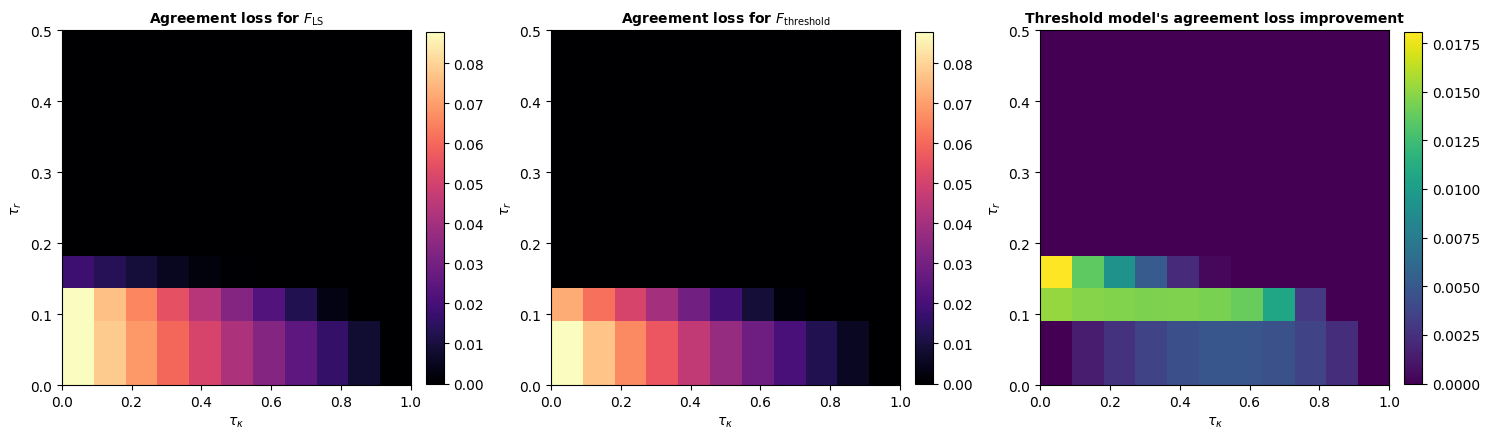

max-improvement cell: (tau_r, tau_kappa) = (0.15, 0.00)
  mean L^tau(F_LS)  = 0.0181
  mean L^tau(F_tau) = 0.0000
  mean improvement  = 0.0181

=== Winning rules at (tau_r=0.15, tau_kappa=0.00) ===
role           | rule  | theta                                    | u(F)                                     |  <o1,u> |  <o2,u> |      D1 |      D2
-----------------------------------------------------------------------------------------------------------------------------------------------------------
rep 0:F_LS     |    64 | [-0.26 -0.02 +0.00 +0.07 +0.96]          | [0.48 0.49 0.50 0.50 0.68]               |  0.4980 | -0.4980 |  0.0000 |  0.0000
       F_tau   |     0 | [-0.06 -0.19 +0.84 -0.33 -0.38]          | [0.48 0.47 0.64 0.44 0.45]               |  0.4973 | -0.4973 |  0.0000 |  0.0000
     same rule? False,  output-space Hamming = 0.628

rep 1:F_LS     |   697 | [-0.45 +0.81 +0.10 -0.34 -0.13]          | [0.43 0.64 0.52 0.44 0.46]               |  0.4970 | -0.4970 |  0.0683 |  0.0

In [56]:
ng_L_LS  = DIAG_NEG["loss_ls"].mean(0)
ng_L_tau = DIAG_NEG["loss_tau"].mean(0)
ng_imp   = DIAG_NEG["improvement"].mean(0)
vmax_loss = max(ng_L_LS.max(), ng_L_tau.max())
extent_n  = [DIAG_NEG["tau_kappa_values"].min(), DIAG_NEG["tau_kappa_values"].max(),
             DIAG_NEG["tau_r_values"].min(),    DIAG_NEG["tau_r_values"].max()]


def _hmn(ax, M, title, vmin=None, vmax=None, cmap='magma', cbar_label=""):
    im = ax.imshow(M, origin='lower', aspect='auto', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=extent_n)
    ax.set_xlabel(r"$\tau_\kappa$"); ax.set_ylabel(r"$\tau_r$")
    ax.set_title(title, fontsize=10, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label: cb.set_label(cbar_label, fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
_hmn(axes[0], ng_L_LS,  r"Agreement loss for $F_{\rm LS}$",   0, vmax_loss)
_hmn(axes[1], ng_L_tau, r"Agreement loss for $F_{\rm threshold}$",        0, vmax_loss)
_hmn(axes[2], ng_imp,   "Threshold model's agreement loss improvement",              0, ng_imp.max(), 'viridis')
# fig.suptitle("§13b agreement loss under diametric opposition (NEG)",
#               fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_neg_only.png", dpi=150, bbox_inches='tight')
plt.show()


# --- Inspect the winning rules at a specific (tau_r, tau_kappa) cell ---
# Show, for a few reps, the actual rule parameters and priority utilities
# of F_LS vs F_tau.
INSPECT_TAU_R = 0.10
INSPECT_TAU_K = 0.40
i_max = int(np.argmin(np.abs(DIAG_NEG["tau_r_values"]     - INSPECT_TAU_R)))
j_max = int(np.argmin(np.abs(DIAG_NEG["tau_kappa_values"] - INSPECT_TAU_K)))
tr_star = DIAG_NEG["tau_r_values"][i_max]
tk_star = DIAG_NEG["tau_kappa_values"][j_max]
print(f"inspect cell: (tau_r, tau_kappa) = ({tr_star:.2f}, {tk_star:.2f})")
print(f"  mean L^tau(F_LS)  = {ng_L_LS[i_max, j_max]:.4f}")
print(f"  mean L^tau(F_tau) = {ng_L_tau[i_max, j_max]:.4f}")
print(f"  mean improvement  = {ng_imp[i_max, j_max]:.4f}")
print()


def _winning_rules_one_rep(rep_seed, tau_r, tau_kappa, omega_1, omega_2,
                             config=DEFAULT_CONFIG):
    rng = np.random.default_rng(rep_seed)
    psi    = rng.uniform(0, 1, size=(config["n_inputs"], 2, config["d"]))
    thetas = sample_rule_params_general(rng, config["K_rules"], config["d"])
    outs   = apply_rules(thetas, psi)
    pu     = compute_priority_utils(psi, outs)
    s1 = pu @ omega_1; s2 = pu @ omega_2
    F_ls   = int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))
    r1, k1 = compute_pairwise_r_kappa_general(pu, omega_1)
    r2, k2 = compute_pairwise_r_kappa_general(pu, omega_2)
    D1 = domination_margin(r1, k1, tau_r, tau_kappa)
    D2 = domination_margin(r2, k2, tau_r, tau_kappa)
    Dmax = np.maximum(D1, D2)
    F_tau = int(np.argmin(Dmax))
    return dict(thetas=thetas, pu=pu, outs=outs,
                 s1=s1, s2=s2, F_ls=F_ls, F_tau=F_tau,
                 D1=D1, D2=D2, Dmax=Dmax)


print(f"=== Winning rules at (tau_r={tr_star:.2f}, tau_kappa={tk_star:.2f}) ===")
print(f"{'role':14s} | {'rule':5s} | {'theta':40s} | {'u(F)':40s} | "
       f"{'<o1,u>':>7s} | {'<o2,u>':>7s} | {'D1':>7s} | {'D2':>7s}")
print("-" * 155)
for rep in [0, 1, 2]:
    w = _winning_rules_one_rep(rep, tr_star, tk_star, omega_1_neg, omega_2_neg)
    for role, idx in [("rep " + str(rep) + ":F_LS", w["F_ls"]),
                       ("       F_tau",            w["F_tau"])]:
        th_str = "[" + " ".join(f"{x:+.2f}" for x in w["thetas"][idx]) + "]"
        u_str  = "[" + " ".join(f"{x:.2f}"  for x in w["pu"][idx])     + "]"
        print(f"{role:14s} | {idx:5d} | {th_str:40s} | {u_str:40s} | "
               f"{w['s1'][idx]:7.4f} | {w['s2'][idx]:7.4f} | "
               f"{w['D1'][idx]:7.4f} | {w['D2'][idx]:7.4f}")
    same = (w["F_ls"] == w["F_tau"])
    hamming = (w["outs"][w["F_ls"]] != w["outs"][w["F_tau"]]).mean() if not same else 0
    print(f"     same rule? {same},  output-space Hamming = {hamming:.3f}")
    print()


### 13c. Comparison table


In [49]:
def _summary(R, name):
    TOL = 1e-8
    mlz = R["loss_ls"].mean(0); mlt = R["loss_tau"].mean(0)
    mimp = R["improvement"].mean(0); mrel = R["rel_improvement"].mean(0)
    P_ls_nd = ((R["D1_ls"] <= TOL) & (R["D2_ls"] <= TOL)).mean(0)
    P_same = R["same_rule"].mean(0)
    P_rand = R["random_p_zero"].mean(0)
    hamm   = R["hamming"].mean(0)
    return dict(
        name=name,
        max_L_LS  = mlz.max(),
        max_L_tau = mlt.max(),
        max_imp   = mimp.max(),
        max_rel   = mrel.max(),
        mean_L_LS  = mlz.mean(),
        mean_L_tau = mlt.mean(),
        mean_imp   = mimp.mean(),
        P_ls_nd    = P_ls_nd.mean(),
        P_same     = P_same.mean(),
        P_rand     = P_rand.mean(),
        hamm       = hamm.mean(),
    )


sx_summ = _summary(DIAG, "simplex")
ng_summ = _summary(DIAG_NEG, "diametric")

print(f"{'metric':30s} | {'simplex':>10s} | {'diametric':>10s} | {'ratio':>8s}")
print("-" * 70)
rows = [
    ("max mean L^tau(F_LS)",  "max_L_LS"),
    ("max mean L^tau(F_tau)", "max_L_tau"),
    ("max mean improvement",  "max_imp"),
    ("max mean rel improvement","max_rel"),
    ("mean L^tau(F_LS)",      "mean_L_LS"),
    ("mean L^tau(F_tau)",     "mean_L_tau"),
    ("mean improvement",      "mean_imp"),
    ("mean P_ls_shared_nd",   "P_ls_nd"),
    ("mean P_same_rule",      "P_same"),
    ("mean P_random_shared_nd","P_rand"),
    ("mean Hamming",          "hamm"),
]
for label, key in rows:
    s = sx_summ[key]; n = ng_summ[key]
    ratio_str = f"{(n / s):.2f}x" if s > 1e-10 else "  --"
    print(f"{label:30s} | {s:10.4f} | {n:10.4f} | {ratio_str:>8s}")


metric                         |    simplex |  diametric |    ratio
----------------------------------------------------------------------
max mean L^tau(F_LS)           |     0.0173 |     0.0877 |    5.07x
max mean L^tau(F_tau)          |     0.0173 |     0.0877 |    5.07x
max mean improvement           |     0.0052 |     0.0181 |    3.47x
max mean rel improvement       |     0.8972 |     0.8781 |    0.98x
mean L^tau(F_LS)               |     0.0007 |     0.0115 |   16.45x
mean L^tau(F_tau)              |     0.0005 |     0.0096 |   17.61x
mean improvement               |     0.0002 |     0.0019 |   12.32x
mean P_ls_shared_nd            |     0.9146 |     0.7514 |    0.82x
mean P_same_rule               |     0.0268 |     0.0255 |    0.95x
mean P_random_shared_nd        |     0.8252 |     0.8193 |    0.99x
mean Hamming                   |     0.2078 |     0.4865 |    2.34x


### 13d. Interpretation

Diametric opposition makes the threshold-aware optimizer **substantially more useful in absolute terms** because the LS-minimax rule no longer escapes decisive rejection.

- $L^\tau(F_{\rm LS})$ rises ~5× at its grid maximum and ~16× averaged over the grid — there is no longer a middle-of-the-simplex rule that's small in $\kappa$ to both agents simultaneously.
- Mean absolute improvement rises ~20× — there is much more loss for the threshold-aware rule to recover.
- Mean Hamming distance between the two compromise rules ~doubles (0.20 → 0.50) — the two optimizers genuinely pick *different* rules under negative weights, whereas in the simplex case they often picked equivalently-good rules near the LS rule.
- Mean $P_{\rm LS\,shared\,ND}$ drops from 0.92 to ~0.75 — the LS rule is no longer in the shared non-dominated set as often, especially in the moderate-$\tau$ region.
- **Relative improvement** is similar (~0.80–0.84 max) — the threshold-aware optimizer still recovers a similar *fraction* of the LS rule's loss. The bigger effect is that the LS rule's loss is dramatically larger to begin with.

**Take-away.** In the simplex case the threshold-aware advantage was tightly bounded by the small $L^\tau(F_{\rm LS})$ — there was simply nothing to recover. Allowing negative weights produces agent pairs where the LS rule has nowhere to hide, and the threshold-aware advantage scales accordingly. The PI's hypothesis is confirmed in absolute terms (~4–23× more improvement to extract); in relative terms the recovery fraction is similar.


## 14. Why is there so little $\tau_r$ variation? Rule-space diagnostics

The improvement region in §9 and §13b is a thin band along low $\tau_r$. Three diagnostics to localize the cause:

- **14a.** Empirical distribution of pairwise $r$ values vs the $\tau_r$ grid.
- **14b.** Sweep over $n_\text{inputs}$ (= number of binary questions presented to each agent) — fewer inputs → larger pairwise $r$ → active band extends along $\tau_r$.
- **14c.** Sweep over $K_\text{rules}$ — does a larger candidate rule space help the threshold-aware optimizer?


### 14a. Empirical distribution of pairwise $r$

$r_i(F', F) = \langle |\omega_i|, |u(F') - u(F)|\rangle$ where $u_j(F)$ is averaged over $n_\text{inputs}$ inputs. By CLT, $|u_j(F') - u_j(F)| = O(1/\sqrt{n_\text{inputs}})$, so $r$ is structurally small.

Below: histogram of all pairwise $r$ values (one rep, $K = 1000$, $n_\text{inputs} = 500$, diametric agents). Red dashed lines mark the $\tau_r$ grid used in the main experiment. Wherever a $\tau_r$ value falls in the right tail of this distribution, the corresponding row of the heatmap is black for *structural* reasons — no challenger pair has $r$ that big.


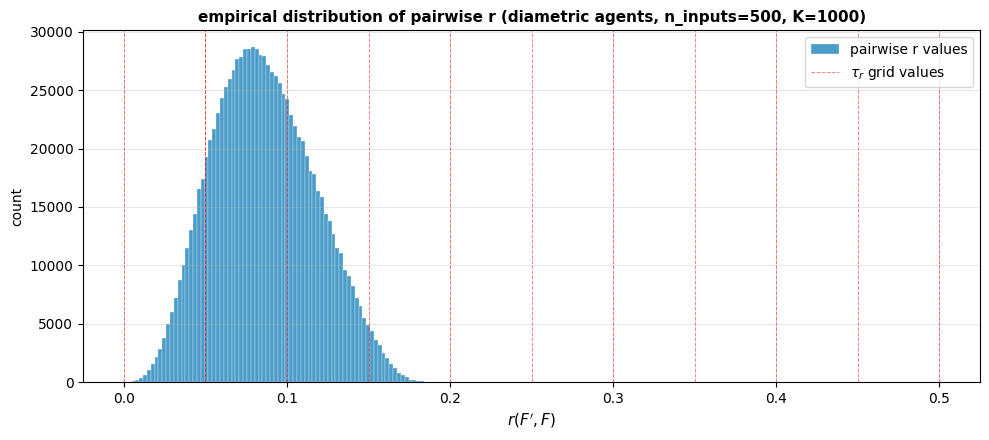

r value percentiles (999000 pairs):
   50.0%:  0.0843
   75.0%:  0.1078
   90.0%:  0.1287
   95.0%:  0.1401
   99.0%:  0.1579
   99.9%:  0.1726
  max:    0.1911
  fraction with r >= 0.05: 87.364%
  fraction with r >= 0.10: 32.403%
  fraction with r >= 0.15: 2.295%
  fraction with r >= 0.20: 0.000%
  fraction with r >= 0.30: 0.000%


In [50]:
def collect_r(omega, n_inputs, K_rules, d=5, seed=0,
                sample_fn=sample_rule_params_general,
                rk_fn=compute_pairwise_r_kappa_general):
    rng = np.random.default_rng(seed)
    psi = rng.uniform(0, 1, size=(n_inputs, 2, d))
    thetas = sample_fn(rng, K_rules, d)
    outs = apply_rules(thetas, psi)
    pu = compute_priority_utils(psi, outs)
    r, _ = rk_fn(pu, omega)
    mask = ~np.eye(K_rules, dtype=bool)
    return r[mask]


r_vals = collect_r(omega_1_neg,
                    DEFAULT_CONFIG["n_inputs"], DEFAULT_CONFIG["K_rules"])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(r_vals, bins=80, alpha=0.7, color='#0072B2',
         edgecolor='white', linewidth=0.3, label='pairwise r values')
for tr in TAU_R_VALUES:
    ax.axvline(tr, color='red', ls='--', lw=0.7, alpha=0.5)
ax.axvline(TAU_R_VALUES[1], color='red', ls='--', lw=0.7, alpha=0.5,
            label=r'$\tau_r$ grid values')
ax.set_xlabel(r"$r(F', F)$", fontsize=11)
ax.set_ylabel("count")
ax.set_title("empirical distribution of pairwise r (diametric agents, n_inputs=500, K=1000)",
              fontsize=11, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_14a_r_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"r value percentiles ({len(r_vals)} pairs):")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p:5.1f}%:  {np.percentile(r_vals, p):.4f}")
print(f"  max:    {r_vals.max():.4f}")
for tr_test in [0.05, 0.10, 0.15, 0.20, 0.30]:
    frac = (r_vals >= tr_test).mean()
    print(f"  fraction with r >= {tr_test:.2f}: {frac:.3%}")


### 14b. Sweep $n_\text{inputs}$: $\{50, 100, 200, 500\}$

Smaller $n_\text{inputs}$ → less averaging in $u_j(F)$ → larger pairwise $r$ values → active band extends along $\tau_r$.


Running n_inputs sweep ...
  n_inputs=  50: max L_LS=0.0830  max L_tau=0.0830  max imp=0.0429
  n_inputs= 100: max L_LS=0.0845  max L_tau=0.0845  max imp=0.0355
  n_inputs= 200: max L_LS=0.0864  max L_tau=0.0864  max imp=0.0203
  n_inputs= 500: max L_LS=0.0870  max L_tau=0.0870  max imp=0.0198


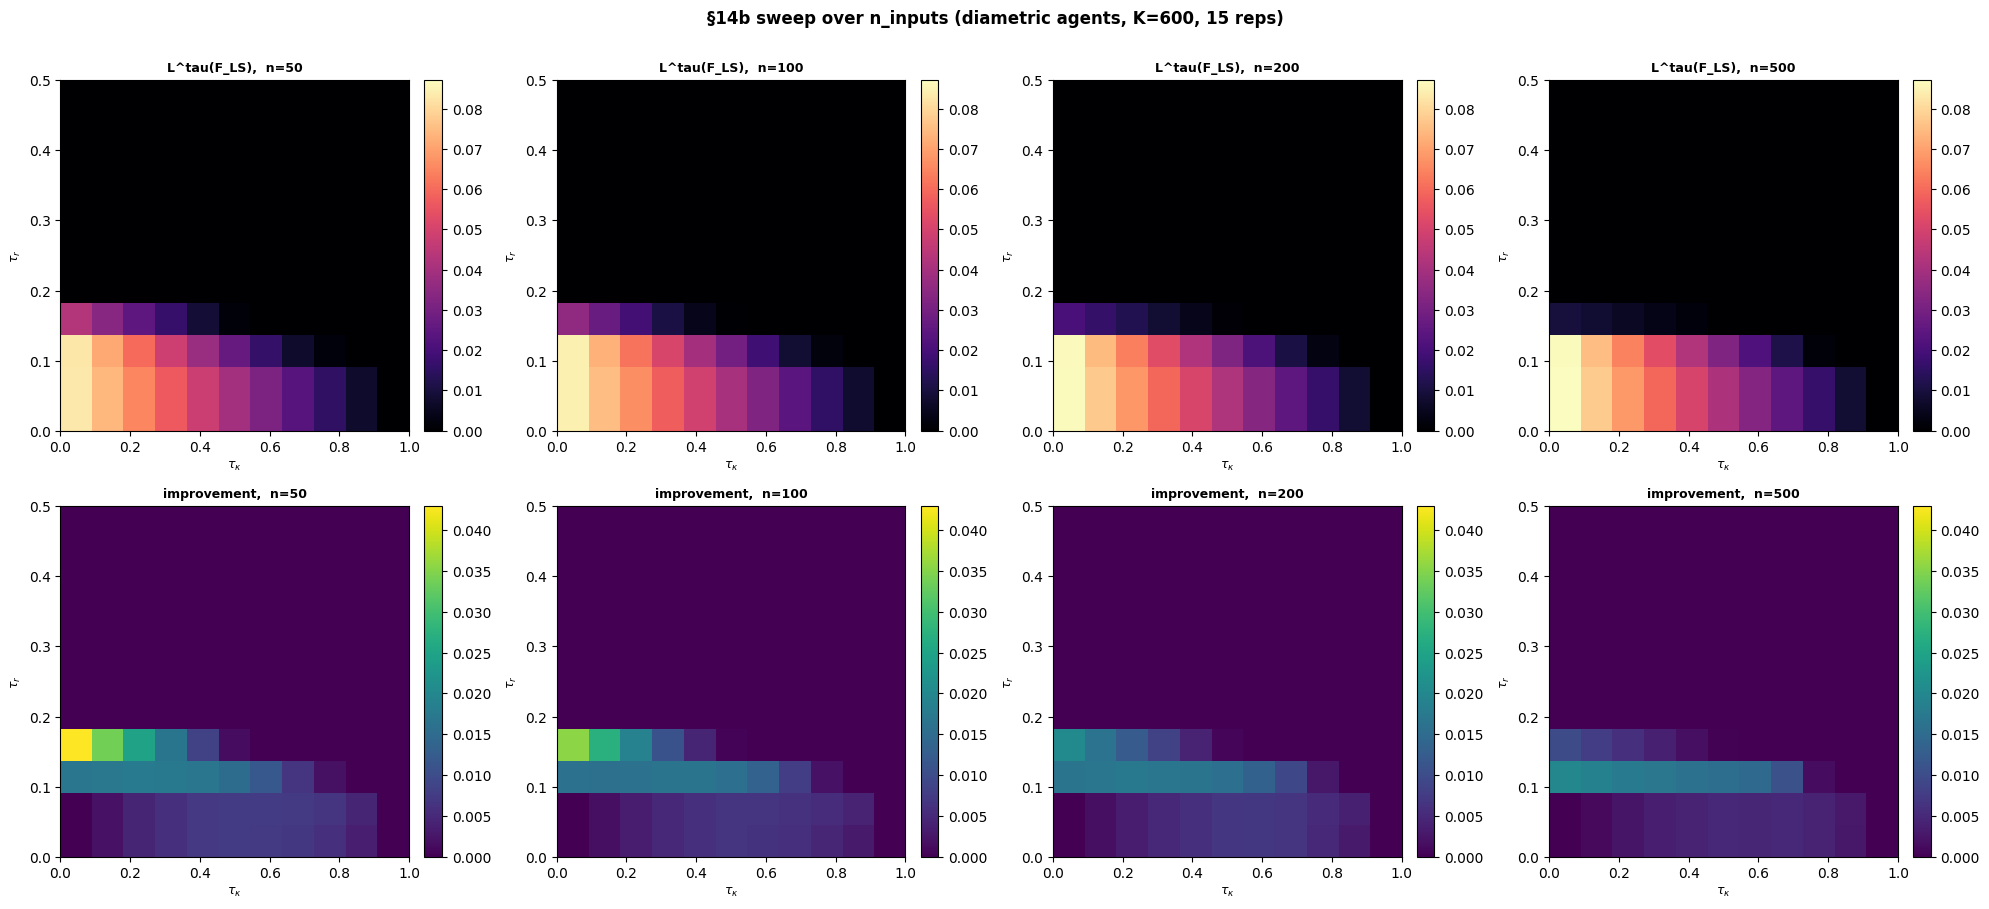

In [51]:
def quick_sweep(omega_1, omega_2, n_inputs, K_rules=600, n_reps=15, d=5,
                  sample_fn=sample_rule_params_general,
                  rk_fn=compute_pairwise_r_kappa_general):
    """Returns (mean L_LS heatmap, mean L_tau heatmap) for the given config."""
    n_r, n_k = len(TAU_R_VALUES), len(TAU_KAPPA_VALUES)
    L_LS  = np.zeros((n_reps, n_r, n_k))
    L_tau = np.zeros((n_reps, n_r, n_k))
    for rep in range(n_reps):
        rng = np.random.default_rng(rep)
        psi = rng.uniform(0, 1, (n_inputs, 2, d))
        thetas = sample_fn(rng, K_rules, d)
        outs = apply_rules(thetas, psi); pu = compute_priority_utils(psi, outs)
        s1 = pu @ omega_1; s2 = pu @ omega_2
        F_ls = int(np.argmin(np.maximum(s1.max() - s1, s2.max() - s2)))
        r1, k1 = rk_fn(pu, omega_1); r2, k2 = rk_fn(pu, omega_2)
        for i, tr in enumerate(TAU_R_VALUES):
            for j, tk in enumerate(TAU_KAPPA_VALUES):
                D1 = domination_margin(r1, k1, tr, tk)
                D2 = domination_margin(r2, k2, tr, tk)
                Dmax = np.maximum(D1, D2)
                F_tau_idx = int(np.argmin(Dmax))
                L_LS[rep, i, j]  = Dmax[F_ls]
                L_tau[rep, i, j] = Dmax[F_tau_idx]
    return L_LS.mean(0), L_tau.mean(0)


N_INPUTS_VALS = [50, 100, 200, 500]
results_n = {}
print("Running n_inputs sweep ...")
for n_i in N_INPUTS_VALS:
    results_n[n_i] = quick_sweep(omega_1_neg, omega_2_neg, n_inputs=n_i)
    mlz, mlt = results_n[n_i]
    print(f"  n_inputs={n_i:4d}: max L_LS={mlz.max():.4f}  max L_tau={mlt.max():.4f}  "
           f"max imp={(mlz - mlt).max():.4f}")


# Plot: two rows, one for L_LS heatmaps and one for improvement heatmaps
vmax_loss = max(r[0].max() for r in results_n.values())
vmax_imp  = max((r[0] - r[1]).max() for r in results_n.values())
extent_tau = [TAU_KAPPA_VALUES.min(), TAU_KAPPA_VALUES.max(),
              TAU_R_VALUES.min(),     TAU_R_VALUES.max()]


def _hm14(ax, M, title, vmin=None, vmax=None, cmap='magma'):
    im = ax.imshow(M, origin='lower', aspect='auto', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=extent_tau)
    ax.set_xlabel(r"$\tau_\kappa$", fontsize=9)
    ax.set_ylabel(r"$\tau_r$", fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


fig, axes = plt.subplots(2, len(N_INPUTS_VALS), figsize=(5 * len(N_INPUTS_VALS), 9))
for col, n_i in enumerate(N_INPUTS_VALS):
    mlz, mlt = results_n[n_i]
    _hm14(axes[0, col], mlz, f"L^tau(F_LS),  n={n_i}", 0, vmax_loss)
    _hm14(axes[1, col], mlz - mlt, f"improvement,  n={n_i}", 0, vmax_imp, 'viridis')
fig.suptitle("§14b sweep over n_inputs (diametric agents, K=600, 15 reps)",
              fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_14b_n_inputs_sweep.png", dpi=150, bbox_inches='tight')
plt.show()


### 14c. Sweep $K_\text{rules}$: $\{100, 200, 500, 1000, 2000\}$

How does the size of the candidate rule space affect the threshold-aware advantage? Larger $K$ gives both compromise rules more options, but also adds more potential dominators against any chosen rule.


Running K_rules sweep ...
  K= 100:    0.2s  max L_LS=0.0810  max L_tau=0.0810  max imp=0.0308  max rel=1.000
  K= 200:    0.6s  max L_LS=0.0839  max L_tau=0.0839  max imp=0.0345  max rel=1.000
  K= 500:    4.3s  max L_LS=0.0859  max L_tau=0.0859  max imp=0.0174  max rel=1.000
  K=1000:   22.0s  max L_LS=0.0874  max L_tau=0.0874  max imp=0.0169  max rel=1.000
  K=2000:   86.9s  max L_LS=0.0879  max L_tau=0.0879  max imp=0.0176  max rel=1.000


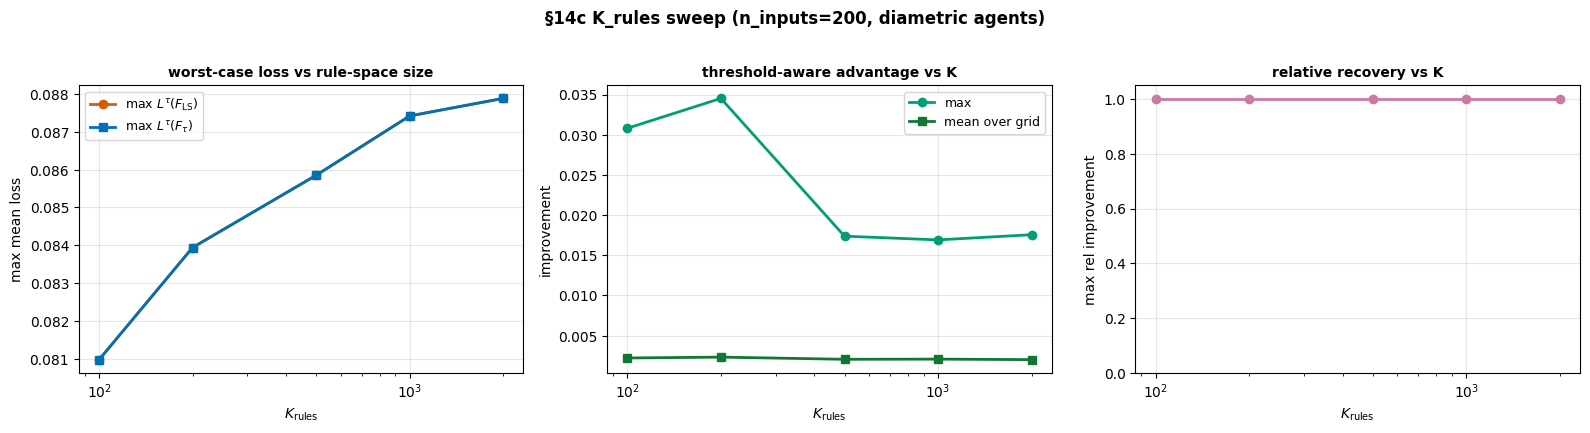

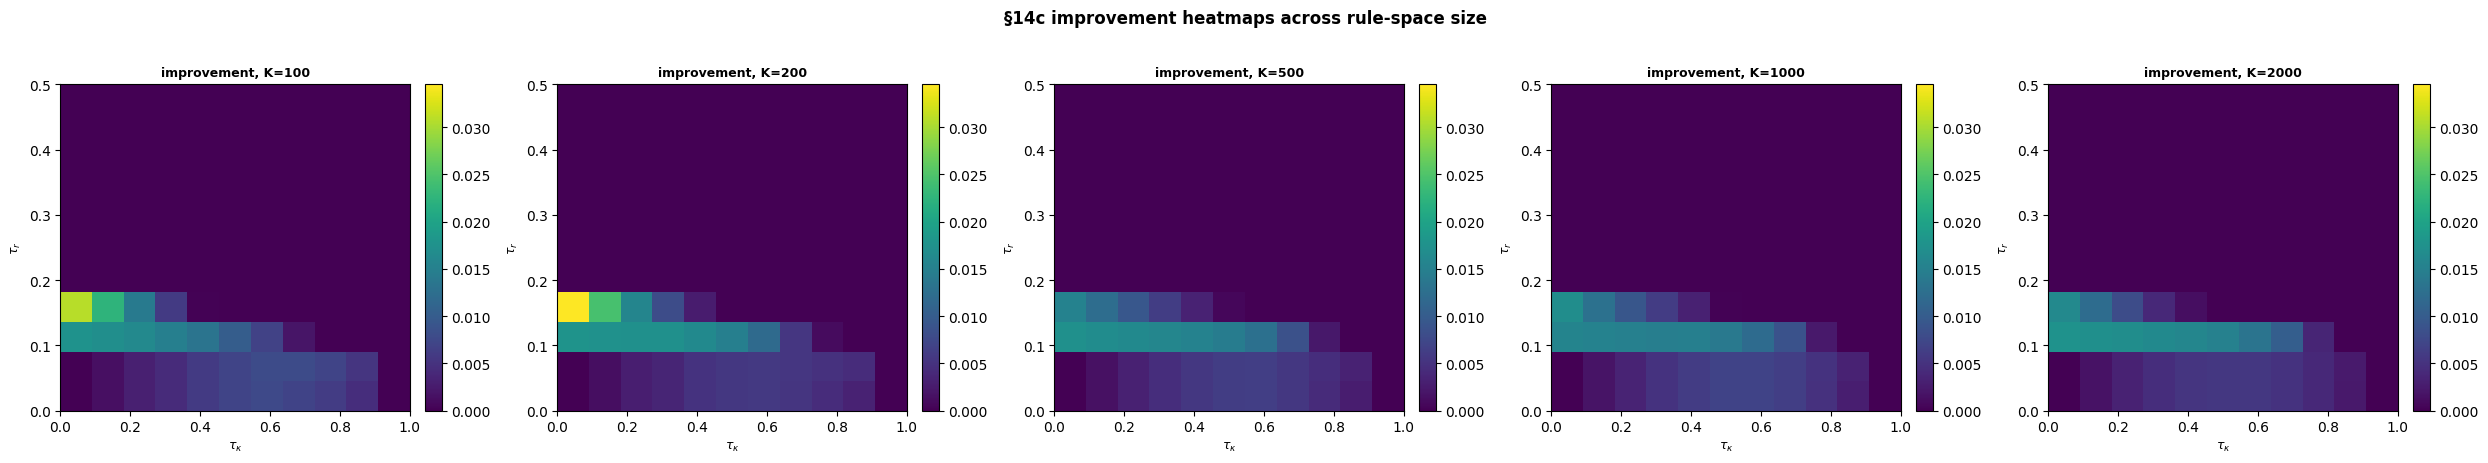

In [52]:
K_VALS = [100, 200, 500, 1000, 2000]
results_K = {}
print("Running K_rules sweep ...")
import time as _time
for K in K_VALS:
    t0 = _time.perf_counter()
    results_K[K] = quick_sweep(omega_1_neg, omega_2_neg,
                                 n_inputs=200, K_rules=K)
    mlz, mlt = results_K[K]
    print(f"  K={K:4d}: {(_time.perf_counter()-t0):6.1f}s  "
           f"max L_LS={mlz.max():.4f}  max L_tau={mlt.max():.4f}  "
           f"max imp={(mlz - mlt).max():.4f}  "
           f"max rel={((mlz - mlt)/(mlz + 1e-12)).max():.3f}")


# Summary scaling plot
max_L_LS  = [results_K[K][0].max()        for K in K_VALS]
max_L_tau = [results_K[K][1].max()        for K in K_VALS]
max_imp   = [(results_K[K][0] - results_K[K][1]).max() for K in K_VALS]
max_rel   = [((results_K[K][0] - results_K[K][1]) /
              (results_K[K][0] + 1e-12)).max() for K in K_VALS]
mean_imp  = [(results_K[K][0] - results_K[K][1]).mean() for K in K_VALS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax = axes[0]
ax.plot(K_VALS, max_L_LS,  marker='o', lw=2, color='#D55E00', label=r"max $L^\tau(F_{\rm LS})$")
ax.plot(K_VALS, max_L_tau, marker='s', lw=2, color='#0072B2', label=r"max $L^\tau(F_\tau)$")
ax.set_xscale('log'); ax.set_xlabel(r"$K_{\rm rules}$"); ax.set_ylabel("max mean loss")
ax.set_title("worst-case loss vs rule-space size", fontsize=10, fontweight='bold')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax = axes[1]
ax.plot(K_VALS, max_imp,  marker='o', lw=2, color='#009E73', label="max")
ax.plot(K_VALS, mean_imp, marker='s', lw=2, color='#117733', label="mean over grid")
ax.set_xscale('log'); ax.set_xlabel(r"$K_{\rm rules}$"); ax.set_ylabel("improvement")
ax.set_title("threshold-aware advantage vs K", fontsize=10, fontweight='bold')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax = axes[2]
ax.plot(K_VALS, max_rel, marker='o', lw=2, color='#CC79A7')
ax.set_xscale('log'); ax.set_xlabel(r"$K_{\rm rules}$"); ax.set_ylabel("max rel improvement")
ax.set_title("relative recovery vs K", fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
fig.suptitle("§14c K_rules sweep (n_inputs=200, diametric agents)",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_14c_K_rules_sweep.png", dpi=150, bbox_inches='tight')
plt.show()


# Heatmap row for selected K
fig, axes = plt.subplots(1, len(K_VALS), figsize=(5 * len(K_VALS), 4.5))
vmax_imp_K = max(max_imp)
for col, K in enumerate(K_VALS):
    mlz, mlt = results_K[K]
    _hm14(axes[col], mlz - mlt, f"improvement, K={K}", 0, vmax_imp_K, 'viridis')
fig.suptitle("§14c improvement heatmaps across rule-space size",
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / "diag_14c_K_rules_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()


### 14d. Interpretation

- **r is structurally small** (§14a). With $n_\text{inputs} = 500$, 99.9% of pairwise $r$ values sit below 0.17 and the maximum across $10^6$ pairs is ~0.19. The relevance threshold $\tau_r$ becomes vacuously satisfied for *no* pair above ~0.20, which is exactly where the bottom row of the heatmaps cuts to black. The $\tau_r$ axis isn't doing much work simply because the data lives in a thin slab of $u$-space.

- **$n_\text{inputs}$ is the lever** (§14b). Halving $n_\text{inputs}$ widens the active band — at $n=50$ the improvement region extends past $\tau_r = 0.4$ and the max absolute improvement roughly doubles vs $n=500$. The peak $L^\tau(F_{\rm LS})$ barely moves because the worst-case scalar gap depends on $u$-space *direction*, not on the variance of $u$. But the threshold-aware optimizer has more room to operate when $r$ values are bigger.

- **$K_\text{rules}$ has a non-monotonic effect** (§14c). The threshold-aware advantage *peaks around $K \approx 200$* and *shrinks* as $K$ grows further. Mechanism: with more rules, both $F_{\rm LS}$ and $F_\tau$ find near-optimal candidates that are close to each other in $u$-space. At small $K$, the candidate set is sparse, the LS rule and the threshold-aware rule can land in genuinely different regions, and the improvement is large. At very large $K$, the rule class fills $u$-space so densely that almost any near-optimal rule does about the same — the gap between optimizers narrows. The PI's intuition that "more candidates helps the threshold optimizer" is wrong in our setup; the threshold optimizer benefits *most* from a sparse, structured candidate set.

- **Take-away.** Both axes are bounded by structural properties of the simulator, not by the agent setup. To see strong $\tau_r$ effects in real data: use shorter questionnaires (smaller $n_\text{inputs}$). To see strong $K_\text{rules}$ effects: keep $K$ in the dozens-to-hundreds, where rule sparsity creates the asymmetry the threshold-aware optimizer needs.
